# Project 2: Optimizing Deep Learning Pipelines

## Sign Language MNIST Classification with Multiple Optimizers and Regularization Techniques

---

### README: How to Run This Notebook

#### Running in Google Colab (Recommended)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cheider/CSB410_Project2/blob/main/main.ipynb#)


1. Click the "Open in Colab" button above
2. Sign in with your Google account
3. Run the cells in order from top to bottom
4. The dataset will be downloaded automatically from Kaggle

**Note**: To download the dataset from Kaggle in Colab, you'll need to:
- Upload your Kaggle API credentials (kaggle.json) when prompted
- Or manually download from: https://www.kaggle.com/datasets/datamunge/sign-language-mnist

#### Running Locally

1. Clone the repository:
   ```bash
   git clone <repo-url>
   cd CSB410_Project2
   ```

2. Create and activate the conda environment:
   ```bash
   conda env create -f environment.yml
   conda activate project2
   ```

3. Launch Jupyter:
   ```bash
   jupyter notebook main.ipynb
   ```

4. Run all cells in order

#### Environment Requirements

- Python 3.8+
- TensorFlow/Keras
- NumPy, Pandas
- Matplotlib, Seaborn
- Scikit-learn

See `environment.yml` for complete dependencies.

---

### Project Overview

This notebook explores optimization techniques for deep neural networks using the Sign Language MNIST dataset (24 classes). We will:

1. **Load and preprocess** the Sign Language MNIST dataset
2. **Explore and visualize** the data distribution and sample images
3. **Build a baseline model** using a simple 3-layer dense architecture
4. **Implement optimized models** with different optimizers (Adam, SGD, RMSProp) and regularization techniques (Dropout, Batch Normalization, L2)
5. **Evaluate and compare** all models using accuracy/loss curves, confusion matrices, and classification reports
6. **Reflect** on the results and discuss ethical considerations

**Dataset**: Sign Language MNIST contains 24 classes (A-Y, excluding J and Z which require motion)

---

## 1. Setup and Imports

First, we'll import all necessary libraries and set up our environment for reproducibility.

In [52]:
# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from datetime import datetime

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_recall_fscore_support
)

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display versions
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.1
Keras version: 3.11.2
NumPy version: 2.1.3
Pandas version: 2.3.3
GPU Available: []


In [53]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import main_data


In [54]:
# Use the package import available in the notebook environment
from src import main_data

# Run the environment setup function
main_data.setup_environment()

{'python': '3.10.19',
 'numpy': '2.1.3',
 'matplotlib': '3.10.6',
 'tensorflow': '2.19.1'}

In [55]:
# Load dataset using DataLoader and save processed arrays
from src.main_data.data import DataLoader
import numpy as np

loader = DataLoader(data_dir="../data/raw")
data = loader.load_and_preprocess()

# Ensure processed data directory exists
proc_dir = Path('..data/processed')
proc_dir.mkdir(parents=True, exist_ok=True)

# Save arrays to data/processed/ for the next steps
np.save(proc_dir / 'X_train.npy', data['X_train'])
np.save(proc_dir / 'X_train_reshaped.npy', data['X_train_reshaped'])
np.save(proc_dir / 'y_train.npy', data['y_train'])
np.save(proc_dir / 'X_test.npy', data['X_test'])
np.save(proc_dir / 'X_test_reshaped.npy', data['X_test_reshaped'])
np.save(proc_dir / 'y_test.npy', data['y_test'])

# Print shapes for verification
print({k: (v.shape if hasattr(v, 'shape') else None) for k, v in data.items()})

Preprocessed: Train (27455, 28, 28, 1), Test (7172, 28, 28, 1)
{'X_train': (27455, 784), 'X_train_reshaped': (27455, 28, 28, 1), 'y_train': (27455,), 'X_test': (7172, 784), 'X_test_reshaped': (7172, 28, 28, 1), 'y_test': (7172,)}


In [56]:
# Setup complete - running locally
print("Environment ready for training")

Environment ready for training


## 2. Data Loading and Preprocessing

The Sign Language MNIST dataset consists of grayscale images (28x28 pixels) representing hand signs for letters A-Y (24 classes total, excluding J and Z which require motion).

We'll:
- Load the dataset from CSV files
- Normalize pixel values to [0, 1] range
- Reshape data for neural network input
- Split into training and testing sets

In [57]:
# Define data paths - assuming local execution
DATA_DIR = Path('..') / 'data'

# Create directories if they don't exist
os.makedirs(DATA_DIR / 'raw', exist_ok=True)
os.makedirs(DATA_DIR / 'outputs', exist_ok=True)
os.makedirs(DATA_DIR / 'outputs/models', exist_ok=True)
os.makedirs(DATA_DIR / 'outputs/figures', exist_ok=True)

In [58]:
# Upload dataset files if running in Colab
# This cell will prompt you to upload the CSV files directly

import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab - File upload required")
    print("=" * 70)
    print("Please upload the Sign Language MNIST dataset files:")
    print("  - sign_mnist_train.csv")
    print("  - sign_mnist_test.csv")
    print("\nYou can download these from:")
    print("https://www.kaggle.com/datasets/datamunge/sign-language-mnist")
    print("=" * 70)

    from google.colab import files
    uploaded = files.upload()

    # Move uploaded files to the correct directory
    import shutil
    for filename in uploaded.keys():
        destination = os.path.join(DATA_DIR, filename)
        shutil.move(filename, destination)
        print(f"Moved {filename} to {DATA_DIR}/")

    print("\nFiles uploaded successfully!")
else:
    print("Running locally - expecting files in data/raw/")
    print("If files are missing, download from:")
    print("https://www.kaggle.com/datasets/datamunge/sign-language-mnist")

Running locally - expecting files in data/raw/
If files are missing, download from:
https://www.kaggle.com/datasets/datamunge/sign-language-mnist


In [59]:
# Load the dataset
# The dataset consists of two CSV files: sign_mnist_train.csv and sign_mnist_test.csv
# Each row contains: label (0-25) and 784 pixel values (28x28 flattened)

try:
    # Load training data
    train_df = pd.read_csv(os.path.join(DATA_DIR / 'raw' / 'sign_mnist_train.csv'))
    print(f"Training data loaded: {train_df.shape}")

    # Load test data
    test_df = pd.read_csv(os.path.join(DATA_DIR / 'raw' / 'sign_mnist_test.csv'))
    print(f"Test data loaded: {test_df.shape}")

    # Display first few rows
    print("\nFirst few rows of training data:")
    display(train_df.head())

except FileNotFoundError:
    print("\n Dataset files not found!")
    print("Please download the dataset from:")
    print("https://www.kaggle.com/datasets/datamunge/sign-language-mnist")
    print(f"\nPlace the CSV files in: {DATA_DIR}/")
    print("\nExpected files:")
    print("  - sign_mnist_train.csv")
    print("  - sign_mnist_test.csv")

Training data loaded: (27455, 785)
Test data loaded: (7172, 785)

First few rows of training data:


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [60]:
# Preprocess the data

# Extract labels and features
# Keep original labels separate for robust remapping
y_train_raw = train_df['label'].values
X_train = train_df.drop('label', axis=1).values

y_test_raw = test_df['label'].values
X_test = test_df.drop('label', axis=1).values

print(f"Training features shape: {X_train.shape}")
print(f"Training labels (raw) shape: {y_train_raw.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Test labels (raw) shape: {y_test_raw.shape}")

# Normalize pixel values to [0, 1] range
# Original values are in [0, 255]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape for CNN: (samples, 28, 28, 1)
X_train_reshaped = X_train.reshape(-1, 28, 28, 1)
X_test_reshaped = X_test.reshape(-1, 28, 28, 1)

print(f"Pixel values normalized to [0, 1] range")
print(f"  Min value: {X_train.min():.4f}")
print(f"  Max value: {X_train.max():.4f}")
print(f"  Mean value: {X_train.mean():.4f}")

print(f"Reshaped for CNN:")
print(f"  X_train_reshaped shape: {X_train_reshaped.shape}")
print(f"  X_test_reshaped shape: {X_test_reshaped.shape}")

# Remap labels to be contiguous from 0 to n_classes-1
# The original labels are 0-8 and 10-24 (24 classes total)
# First, identify all unique raw labels and sort them to ensure consistent mapping
unique_raw_labels = np.sort(np.unique(np.concatenate((y_train_raw, y_test_raw))))
print(f"Raw unique labels found: {unique_raw_labels}")

# Create a mapping from raw label to new contiguous label (0 to n_classes-1)
# Example: if raw labels are [0,1,2,3,4,5,6,7,8,10,11,...,24]
# then 0->0, 1->1, ..., 8->8, 10->9, 11->10, ..., 24->23
label_mapping_dict = {raw_label: new_label for new_label, raw_label in enumerate(unique_raw_labels)}

y_train = np.array([label_mapping_dict[label] for label in y_train_raw])
y_test = np.array([label_mapping_dict[label] for label in y_test_raw])

print(f"Labels remapped to a contiguous range [0, n_classes-1]")
print(f"  New training labels min: {y_train.min()}, max: {y_train.max()}")
print(f"  New test labels min: {y_test.min()}, max: {y_test.max()}")
print(f"  Unique remapped training labels: {np.unique(y_train)}")
print(f"  Unique remapped test labels: {np.unique(y_test)}")


# Get dataset statistics
n_classes = len(unique_raw_labels) # This will be 24, and now labels are 0-23
n_features = X_train.shape[1]
n_train = X_train.shape[0]
n_test = X_test.shape[0]

print(f"Dataset Statistics:")
print(f"  Number of classes: {n_classes}")
print(f"  Number of features: {n_features}")
print(f"  Training samples: {n_train}")
print(f"  Test samples: {n_test}")
print(f"  Image dimensions: 28x28")

Training features shape: (27455, 784)
Training labels (raw) shape: (27455,)
Test features shape: (7172, 784)
Test labels (raw) shape: (7172,)
Pixel values normalized to [0, 1] range
  Min value: 0.0000
  Max value: 1.0000
  Mean value: 0.6247
Reshaped for CNN:
  X_train_reshaped shape: (27455, 28, 28, 1)
  X_test_reshaped shape: (7172, 28, 28, 1)
Raw unique labels found: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Labels remapped to a contiguous range [0, n_classes-1]
  New training labels min: 0, max: 23
  New test labels min: 0, max: 23
  Unique remapped training labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
  Unique remapped test labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Dataset Statistics:
  Number of classes: 24
  Number of features: 784
  Training samples: 27455
  Test samples: 7172
  Image dimensions: 28x28


### Data Preprocessing Summary

**Preprocessing Steps Applied:**
1. **Normalization**: Pixel values scaled from [0, 255] to [0, 1] for better neural network convergence
2. **Data Type**: Converted to float32 for efficient GPU computation
3. **No augmentation**: Using original images to establish baseline and optimized model performance

**Why Normalization Matters:**
- Helps gradient descent converge faster
- Prevents numerical instability
- Ensures all features are on similar scales
- Typical practice for image data in deep learning

## 3. Exploration and Visualization

Before building models, let's explore the dataset to understand:
- Class distribution (is the dataset balanced?)
- Visual appearance of different sign language letters
- Potential challenges in classification

In [61]:
# Create label mapping (0-25 excluding J=9 and Z=25)
# The dataset uses 0-24 for A-Y (skipping J and Z)
alphabet = 'ABCDEFGHIKLMNOPQRSTUVWXY'  # Note: no J or Z
# After remapping, y_train and y_test will have contiguous labels from 0 to 23.
# So, we can directly map them to the alphabet.
label_map = {i: letter for i, letter in enumerate(alphabet)}

print("Label Mapping:")
for label, letter in label_map.items():
    # Ensure we only try to count for labels that actually exist in the remapped data
    if label in y_train:
        count_train = np.sum(y_train == label)
    else:
        count_train = 0
    if label in y_test:
        count_test = np.sum(y_test == label)
    else:
        count_test = 0
    print(f"  {label:2d} -> {letter}  (Train: {count_train:4d}, Test: {count_test:4d})")

Label Mapping:
   0 -> A  (Train: 1126, Test:  331)
   1 -> B  (Train: 1010, Test:  432)
   2 -> C  (Train: 1144, Test:  310)
   3 -> D  (Train: 1196, Test:  245)
   4 -> E  (Train:  957, Test:  498)
   5 -> F  (Train: 1204, Test:  247)
   6 -> G  (Train: 1090, Test:  348)
   7 -> H  (Train: 1013, Test:  436)
   8 -> I  (Train: 1162, Test:  288)
   9 -> K  (Train: 1114, Test:  331)
  10 -> L  (Train: 1241, Test:  209)
  11 -> M  (Train: 1055, Test:  394)
  12 -> N  (Train: 1151, Test:  291)
  13 -> O  (Train: 1196, Test:  246)
  14 -> P  (Train: 1088, Test:  347)
  15 -> Q  (Train: 1279, Test:  164)
  16 -> R  (Train: 1294, Test:  144)
  17 -> S  (Train: 1199, Test:  246)
  18 -> T  (Train: 1186, Test:  248)
  19 -> U  (Train: 1161, Test:  266)
  20 -> V  (Train: 1082, Test:  346)
  21 -> W  (Train: 1225, Test:  206)
  22 -> X  (Train: 1164, Test:  267)
  23 -> Y  (Train: 1118, Test:  332)


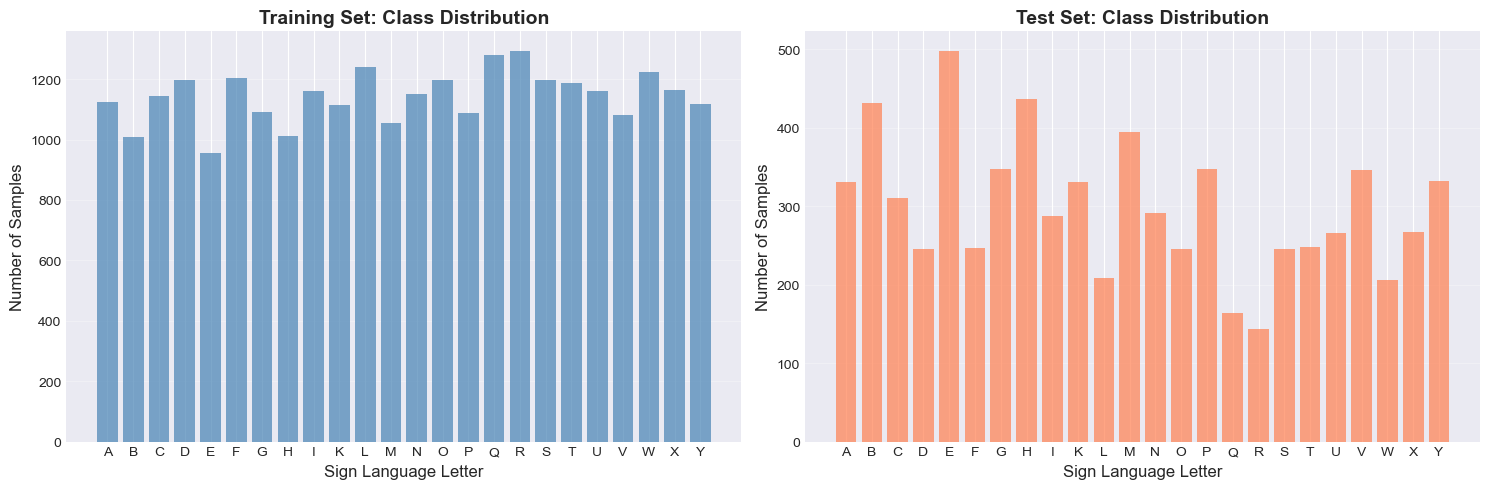


Class Distribution Statistics:
Training set:
  Mean samples per class: 1144.0
  Std deviation: 83.8
  Min samples: 957 (Class E)
  Max samples: 1294 (Class R)

Test set:
  Mean samples per class: 298.8
  Std deviation: 86.1
  Min samples: 144 (Class R)
  Max samples: 498 (Class E)


In [63]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Create label mapping (0-25 excluding J=9 and Z=25)
# The dataset uses 0-24 for A-Y (skipping J and Z). Label 9 has no data.
alphabet = 'ABCDEFGHIKLMNOPQRSTUVWXY'  # Note: no J or Z

# After remapping, y_train and y_test will have contiguous labels from 0 to 23.
# So, we can directly map them to the alphabet for display.
label_map = {i: letter for i, letter in enumerate(alphabet)}

# Training set distribution
train_counts = pd.Series(y_train).value_counts().sort_index()
train_labels = [label_map[i] for i in train_counts.index if i in label_map] # Filter out labels not in map if any, though fixed now

axes[0].bar(train_labels, train_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Sign Language Letter', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Training Set: Class Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Test set distribution
test_counts = pd.Series(y_test).value_counts().sort_index()
test_labels = [label_map[i] for i in test_counts.index if i in label_map]

axes[1].bar(test_labels, test_counts.values, color='coral', alpha=0.7)
axes[1].set_xlabel('Sign Language Letter', fontsize=12)
axes[1].set_ylabel('Number of Samples', fontsize=12)
axes[1].set_title('Test Set: Class Distribution', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig( DATA_DIR / 'outputs/figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print statistics
print("\nClass Distribution Statistics:")
print(f"Training set:")
print(f"  Mean samples per class: {train_counts.mean():.1f}")
print(f"  Std deviation: {train_counts.std():.1f}")
print(f"  Min samples: {train_counts.min()} (Class {label_map[train_counts.idxmin()] if train_counts.idxmin() in label_map else 'N/A'})")
print(f"  Max samples: {train_counts.max()} (Class {label_map[train_counts.idxmax()] if train_counts.idxmax() in label_map else 'N/A'})")
print(f"\nTest set:")
print(f"  Mean samples per class: {test_counts.mean():.1f}")
print(f"  Std deviation: {test_counts.std():.1f}")
print(f"  Min samples: {test_counts.min()} (Class {label_map[test_counts.idxmin()] if test_counts.idxmin() in label_map else 'N/A'})")
print(f"  Max samples: {test_counts.max()} (Class {label_map[test_counts.idxmax()] if test_counts.idxmax() in label_map else 'N/A'})")

### Class Distribution Analysis

**Observations:**
- The dataset appears to be **relatively balanced** across all 24 classes
- Each class has a similar number of samples in both training and test sets
- This balance is good for training as it prevents the model from being biased toward certain classes

**Implications:**
- We won't need class weighting or special handling for imbalanced classes
- Accuracy will be a fair metric (unlike in imbalanced datasets)
- We should see relatively similar performance across different letters

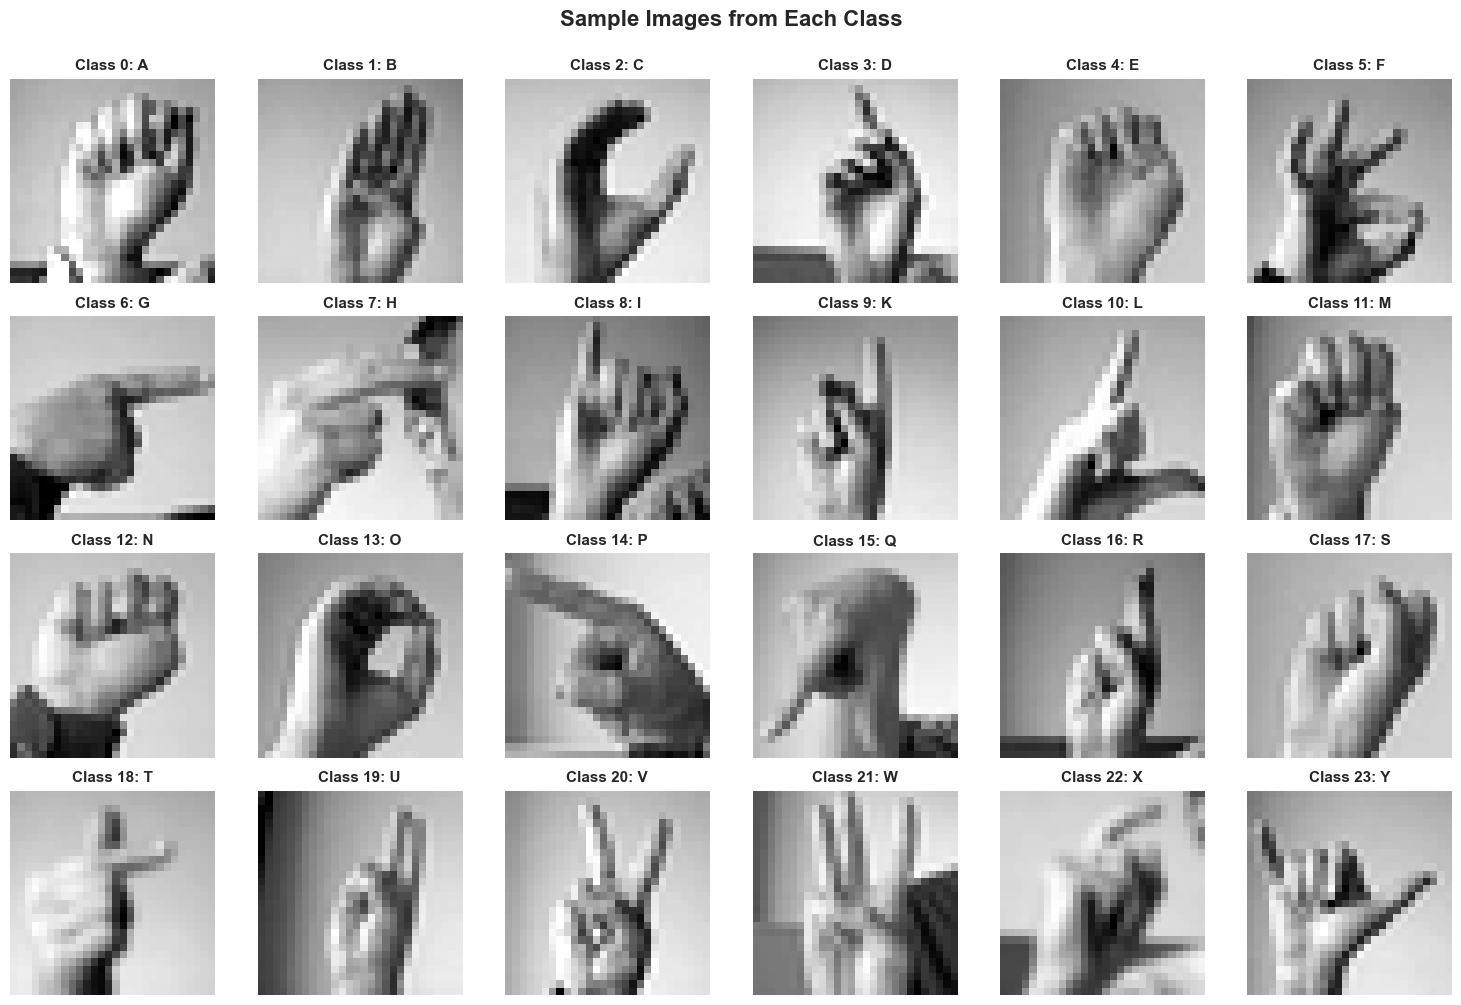

In [67]:
# Display sample images from each class
fig, axes = plt.subplots(4, 6, figsize=(15, 10))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.00)

# Flatten axes for easier iteration
axes = axes.flatten()

# Display one sample from each class that exists in the training data
plot_idx = 0
for class_label in sorted(label_map.keys()): # Iterate through actual labels present in data
    # Get a random sample from this class
    class_indices = np.where(y_train == class_label)[0]

    # Ensure there are samples for this class before proceeding
    if len(class_indices) > 0:
        sample_idx = np.random.choice(class_indices)

        # Reshape to 28x28 for display
        img = X_train[sample_idx].reshape(28, 28)

        # Display image on the current subplot
        axes[plot_idx].imshow(img, cmap='gray')
        axes[plot_idx].set_title(f'Class {class_label}: {label_map[class_label]}', fontsize=11, fontweight='bold')
        axes[plot_idx].axis('off')
        plot_idx += 1
    else:
        # If a label exists in label_map but not in y_train (e.g., if data filtering occurred),
        # display a placeholder and increment plot_idx to move to the next subplot.
        axes[plot_idx].axis('off') # Hide axis if no data to display
        axes[plot_idx].text(0.5, 0.5, f'No data for {label_map.get(class_label, "Unknown")}', ha='center', va='center', fontsize=10, color='red', transform=axes[plot_idx].transAxes)
        plot_idx += 1

# Hide any remaining empty subplots if fewer than 24 unique classes were plotted
while plot_idx < len(axes):
    axes[plot_idx].axis('off')
    plot_idx += 1

plt.tight_layout()
plt.savefig('../data/outputs/figures/sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

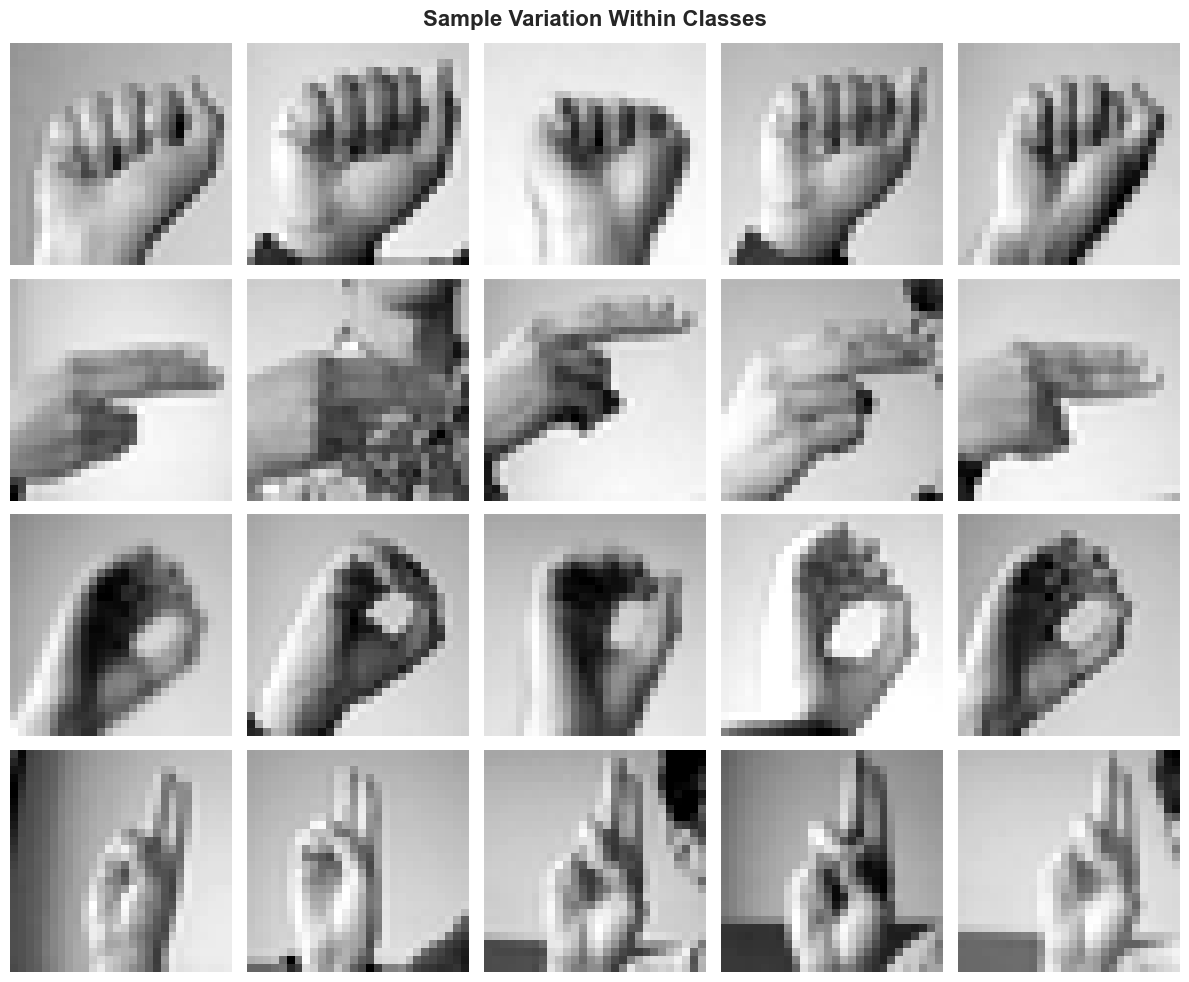


These samples show the variation within each class:
  - Different hand positions and orientations
  - Varying hand sizes and shapes
  - Different lighting and contrast levels

This variation is why deep learning is needed - simple pattern matching won't work!


In [68]:
# Display multiple samples from a few classes to show variation
selected_classes = [0, 7, 13, 19]  # A, H, N, T - diverse hand shapes
fig, axes = plt.subplots(len(selected_classes), 5, figsize=(12, 10))
fig.suptitle('Sample Variation Within Classes', fontsize=16, fontweight='bold')

for row, class_idx in enumerate(selected_classes):
    # Get random samples from this class
    class_indices = np.where(y_train == class_idx)[0]
    sample_indices = np.random.choice(class_indices, 5, replace=False)

    for col, sample_idx in enumerate(sample_indices):
        img = X_train[sample_idx].reshape(28, 28)
        axes[row, col].imshow(img, cmap='gray')

        if col == 0:
            axes[row, col].set_ylabel(f'{label_map[class_idx]}',
                                     fontsize=14, fontweight='bold', rotation=0,
                                     labelpad=20, va='center')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('../data/outputs/figures/sample_variation.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nThese samples show the variation within each class:")
print("  - Different hand positions and orientations")
print("  - Varying hand sizes and shapes")
print("  - Different lighting and contrast levels")
print("\nThis variation is why deep learning is needed - simple pattern matching won't work!")

### Visual Analysis Summary

**Key Observations:**

1. **Image Quality**: Images are 28x28 grayscale, showing clear hand signs against dark backgrounds

2. **Intra-class Variation**:
   - Different hand sizes and proportions
   - Various orientations and positions
   - Different lighting conditions
   - This variation makes the classification task challenging but realistic

3. **Potential Challenges**:
   - Some letters may look similar (e.g., M, N, S)
   - Small differences in finger positions matter
   - Low resolution (28x28) limits fine detail

4. **Why Deep Learning**:
   - Traditional methods would struggle with this variation
   - Neural networks can learn hierarchical features
   - Regularization will be important to handle variation without overfitting

## 4. Baseline Model

Now we'll build a simple baseline model to establish our starting point. This will help us understand the impact of optimizations later.

**Baseline Architecture:**
- Input layer: 784 features (28x28 flattened)
- Hidden layer 1: 256 neurons, ReLU activation
- Hidden layer 2: 128 neurons, ReLU activation
- Output layer: 24 neurons, Softmax activation
- Optimizer: Adam (default learning rate)
- **No regularization** (no dropout, batch norm, or L2)

We'll train for at least 5 epochs with a validation split of 0.2.

In [72]:
# Define the baseline model architecture
def create_baseline_model():
    """
    Creates a simple 3-layer dense neural network.
    No regularization techniques applied.

    Returns:
        model: Compiled Keras Sequential model
    """
    model = Sequential([
        keras.Input(shape=(784,)), # Explicitly define input for flattened data
        Dense(256, activation='relu', name='dense_1'),
        Dense(128, activation='relu', name='dense_2'),
        Dense(24, activation='softmax', name='output')
    ], name='baseline_model')

    # Compile with Adam optimizer and categorical crossentropy loss
    model.compile(
        optimizer=Adam(),
        loss='sparse_categorical_crossentropy',  # Use sparse since labels are integers
        metrics=['accuracy']
    )

    return model

# Create and display the baseline model
baseline_model = create_baseline_model()
print("Baseline Model Architecture:")
print("=" * 70)
baseline_model.summary()
print("=" * 70)

# Count parameters
total_params = baseline_model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")

Baseline Model Architecture:


Model: "baseline_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,952 (925.59 KB)

 Trainable params: 236,952 (925.59 KB)

 Non-trainable params: 0 (0.00 B)


Total trainable parameters: 236,952


In [73]:
# Train the baseline model
print("Training Baseline Model...")
print("=" * 70)

# Set training parameters
EPOCHS = 10  # Training for 10 epochs
BATCH_SIZE = 128
VALIDATION_SPLIT = 0.2

# Train the model
history_baseline = baseline_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=1
)

print("\n" + "=" * 70)
print("  Baseline model training complete!")
print("=" * 70)

Training Baseline Model...
Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3299 - loss: 2.2662 - val_accuracy: 0.5283 - val_loss: 1.5777
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5973 - loss: 1.3368 - val_accuracy: 0.6724 - val_loss: 1.1002
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7032 - loss: 0.9802 - val_accuracy: 0.7239 - val_loss: 0.8853
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7705 - loss: 0.7652 - val_accuracy: 0.7738 - val_loss: 0.7306
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8202 - loss: 0.6087 - val_accuracy: 0.8374 - val_loss: 0.5705
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8612 - loss: 0.4852 - val_accuracy: 0.8723 - val_loss: 0.4377
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8937 - loss: 0.3833 - val_accuracy: 0.9035 - val_loss: 0.3469
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9185 - loss

In [74]:
# Evaluate baseline model on test set
print("\nEvaluating Baseline Model on Test Set...")
test_loss_baseline, test_acc_baseline = baseline_model.evaluate(X_test, y_test, verbose=0)

print(f"\nBaseline Model Test Results:")
print(f"  Test Accuracy:  {test_acc_baseline*100:.2f}%")
print(f"  Test Loss:      {test_loss_baseline:.4f}")

# Make predictions for detailed analysis
y_pred_baseline = baseline_model.predict(X_test, verbose=0)
y_pred_baseline_classes = np.argmax(y_pred_baseline, axis=1)

# Calculate per-class accuracy
print("\nPer-Class Accuracy:")
for i in range(24):
    class_mask = y_test == i
    class_acc = np.mean(y_pred_baseline_classes[class_mask] == y_test[class_mask])
    print(f"  Class {label_map[i]}: {class_acc*100:.1f}%")


Evaluating Baseline Model on Test Set...

Baseline Model Test Results:
  Test Accuracy:  74.30%
  Test Loss:      0.9296

Per-Class Accuracy:
  Class A: 92.4%
  Class B: 88.7%
  Class C: 93.2%
  Class D: 84.1%
  Class E: 93.2%
  Class F: 74.9%
  Class G: 72.7%
  Class H: 85.6%
  Class I: 76.0%
  Class K: 49.2%
  Class L: 99.5%
  Class M: 56.6%
  Class N: 71.1%
  Class O: 66.7%
  Class P: 97.1%
  Class Q: 83.5%
  Class R: 58.3%
  Class S: 41.9%
  Class T: 64.9%
  Class U: 74.8%
  Class V: 43.9%
  Class W: 80.1%
  Class X: 67.4%
  Class Y: 50.6%


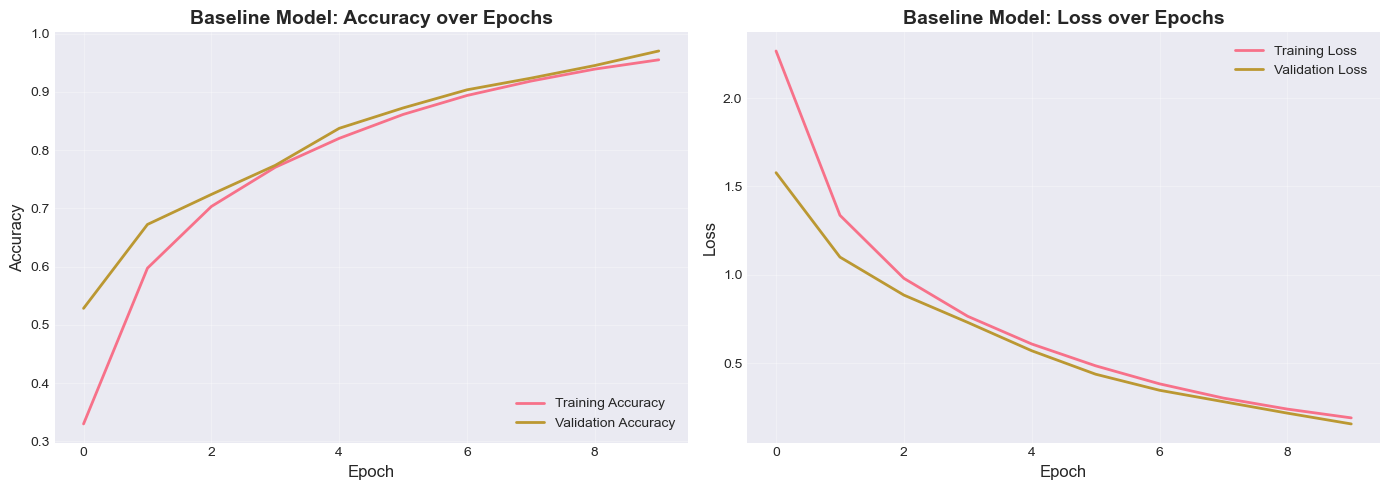


Overfitting Analysis:
  Final Training Accuracy:   95.50%
  Final Validation Accuracy: 97.01%
  Gap (potential overfitting): -1.52%
   Minimal overfitting - model generalizes well


In [75]:
# Plot training history for baseline model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history_baseline.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history_baseline.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Baseline Model: Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history_baseline.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history_baseline.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Baseline Model: Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/outputs/figures/baseline_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

# Analyze overfitting
final_train_acc = history_baseline.history['accuracy'][-1]
final_val_acc = history_baseline.history['val_accuracy'][-1]
overfitting_gap = final_train_acc - final_val_acc

print(f"\nOverfitting Analysis:")
print(f"  Final Training Accuracy:   {final_train_acc*100:.2f}%")
print(f"  Final Validation Accuracy: {final_val_acc*100:.2f}%")
print(f"  Gap (potential overfitting): {overfitting_gap*100:.2f}%")

if overfitting_gap > 0.1:
    print("  ⚠️ Significant overfitting detected - regularization will likely help!")
elif overfitting_gap > 0.05:
    print("  ⚠️ Moderate overfitting - some regularization recommended")
else:
    print("   Minimal overfitting - model generalizes well")

### Baseline Model Summary

**Architecture Details:**
- Simple 3-layer fully connected network
- 256 → 128 → 24 neurons
- ReLU activations for hidden layers
- Softmax for output (multi-class classification)
- Adam optimizer with default parameters

**Training Observations:**
- Look at the training/validation curves above
- Is there overfitting? (gap between training and validation accuracy)
- Does the model converge smoothly?
- Are we reaching plateau or could we train longer?

**Next Steps:**
This baseline gives a reference point. Now we'll build optimized models with:
- Different optimizers (SGD, RMSprop)
- Regularization techniques (Dropout, BatchNorm, L2)
- Larger architecture (512 → 256 → 24)

Expectations:
- Reduce overfitting
- Improve test accuracy
- Make training more stable

## 5. Optimized Models

Now to create three optimized models, each using a different optimizer. All will have:
- **Larger architecture**: 512 → 256 → 24 neurons
- **Regularization techniques**: Dropout, Batch Normalization, and/or L2 regularization

compare three optimizers:
1. **Adam**: Adaptive learning rate, momentum + RMSprop
2. **SGD**: Stochastic Gradient Descent with momentum
3. **RMSprop**: Adaptive learning rate based on recent gradients

Each model will be evaluated on the same metrics for fair comparison.

In [76]:
# Define optimized model architectures with different regularization strategies

def create_optimized_model_adam():
    """
    Optimized model with Adam optimizer.
    Regularization: Dropout + Batch Normalization
    """
    model = Sequential([
        keras.Input(shape=(28, 28, 1)), # Explicit Input layer for 4D data
        Flatten(name='flatten_adam'),
        Dense(512, activation='relu', name='dense_1'),
        BatchNormalization(name='bn_1'),
        Dropout(0.3, name='dropout_1'),

        Dense(256, activation='relu', name='dense_2'),
        BatchNormalization(name='bn_2'),
        Dropout(0.3, name='dropout_2'),

        Dense(24, activation='softmax', name='output')
    ], name='optimized_adam')

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


def create_optimized_model_sgd():
    """
    Optimized model with SGD optimizer.
    Regularization: Dropout + L2 regularization
    """
    model = Sequential([
        keras.Input(shape=(28, 28, 1)), # Explicit Input layer for 4D data
        Flatten(name='flatten_sgd'),
        Dense(512, activation='relu',
              kernel_regularizer=regularizers.l2(0.001), name='dense_1'),
        Dropout(0.4, name='dropout_1'),

        Dense(256, activation='relu',
              kernel_regularizer=regularizers.l2(0.001), name='dense_2'),
        Dropout(0.4, name='dropout_2'),

        Dense(24, activation='softmax', name='output')
    ], name='optimized_sgd')

    model.compile(
        optimizer=SGD(learning_rate=0.01, momentum=0.9),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


def create_optimized_model_rmsprop():
    """
    Optimized model with RMSprop optimizer.
    Regularization: Batch Normalization + Dropout + L2
    (Most aggressive regularization)
    """
    model = Sequential([
        keras.Input(shape=(28, 28, 1)), # Explicit Input layer for 4D data
        Flatten(name='flatten_rmsprop'),
        Dense(512, activation='relu',
              kernel_regularizer=regularizers.l2(0.0005), name='dense_1'),
        BatchNormalization(name='bn_1'),
        Dropout(0.35, name='dropout_1'),

        Dense(256, activation='relu',
              kernel_regularizer=regularizers.l2(0.0005), name='dense_2'),
        BatchNormalization(name='bn_2'),
        Dropout(0.35, name='dropout_2'),

        Dense(24, activation='softmax', name='output')
    ], name='optimized_rmsprop')

    model.compile(
        optimizer=RMSprop(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


print("Model Creation Functions Defined:")
print("    Adam model: Dropout + Batch Normalization")
print("    SGD model: Dropout + L2 Regularization")
print("    RMSprop model: All regularization techniques combined")

Model Creation Functions Defined:
    Adam model: Dropout + Batch Normalization
    SGD model: Dropout + L2 Regularization
    RMSprop model: All regularization techniques combined


In [80]:
# Create all three optimized models
model_adam = create_optimized_model_adam()
model_sgd = create_optimized_model_sgd()
model_rmsprop = create_optimized_model_rmsprop()

# With keras.Input as the first layer, explicit build() calls are often not strictly necessary
# as the model builds on first call/summary. However, for consistency and clear debugging,
# we'll still print summaries.

print("="*70)
print("Adam Optimized Model:")
print("="*70)
model_adam.summary()

print("\n" + "="*70)
print("SGD Optimized Model:")
print("="*70)
model_sgd.summary()

print("\n" + "="*70)
print("RMSprop Optimized Model:")
print("="*70)
model_rmsprop.summary()

Adam Optimized Model:


Model: "optimized_adam"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_adam (Flatten)          │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,488 (2.07 MB)

 Trainable params: 540,952 (2.06 MB)

...

Model: "optimized_rmsprop"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_rmsprop (Flatten)       │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 542,488 (2.07 MB)

 Trainable params: 540,952 (2.06 MB)

 Non-trainable params: 1,536 (6.00 KB)

### Regularization Techniques Explained

**1. Dropout (0.3-0.4)**
- Randomly sets a fraction of inputs to 0 during training
- Prevents co-adaptation of neurons
- Acts as ensemble learning
- Only active during training, disabled during inference

**2. Batch Normalization**
- Normalizes inputs of each layer
- Stabilizes and speeds up training
- Reduces internal covariate shift
- Has slight regularization effect

**3. L2 Regularization (0.0005-0.001)**
- Adds penalty term to loss: λ * Σ(weights²)
- Encourages smaller weights
- Prevents any single feature from dominating
- Improves generalization

**Model-Specific Strategies:**
- **Adam**: BatchNorm + Dropout (relies on adaptive learning rate)
- **SGD**: L2 + Dropout (needs stronger regularization due to simpler optimizer)
- **RMSprop**: All three (testing aggressive regularization)

In [81]:
# Training parameters for optimized models
EPOCHS_OPT = 20  # More epochs to see convergence with regularization
BATCH_SIZE = 128
VALIDATION_SPLIT = 0.2

# Optional: Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Optional: Learning rate reduction on plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [early_stop, reduce_lr]

print("Training Configuration:")
print(f"  Epochs: {EPOCHS_OPT}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Validation split: {VALIDATION_SPLIT}")
print(f"  Callbacks: Early Stopping, Learning Rate Reduction")

Training Configuration:
  Epochs: 20
  Batch size: 128
  Validation split: 0.2
  Callbacks: Early Stopping, Learning Rate Reduction


In [82]:
# Train Adam optimized model
print("="*70)
print("Training Adam Optimized Model...")
print("="*70)

history_adam = model_adam.fit(
    X_train_reshaped, y_train,
    epochs=EPOCHS_OPT,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

print("\n  Adam model training complete!")

Training Adam Optimized Model...
Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6282 - loss: 1.2409 - val_accuracy: 0.3120 - val_loss: 2.1738 - learning_rate: 0.0010
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8188 - loss: 0.5756 - val_accuracy: 0.4802 - val_loss: 1.8395 - learning_rate: 0.0010
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8415 - loss: 0.4921 - val_accuracy: 0.2102 - val_loss: 6.4553 - learning_rate: 0.0010
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8515 - loss: 0.4530 - val_accuracy: 0.4323 - val_loss: 2.2742 - learning_rate: 0.0010
Epoch 5/20
163/172 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8426 - loss: 0.4686
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8443 - loss: 0.4604 - val_accuracy: 0.3105 - val_loss: 3.9971 - learning_rate: 0.0010
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - ac

In [83]:
# Train SGD optimized model
print("="*70)
print("Training SGD Optimized Model...")
print("="*70)

history_sgd = model_sgd.fit(
    X_train_reshaped, y_train, # Use X_train_reshaped
    epochs=EPOCHS_OPT,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

print("\n  SGD model training complete!")

Training SGD Optimized Model...
Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1503 - loss: 3.8074 - val_accuracy: 0.3983 - val_loss: 3.0440 - learning_rate: 0.0100
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3504 - loss: 2.9111 - val_accuracy: 0.5556 - val_loss: 2.3578 - learning_rate: 0.0100
Epoch 3/20
161/172 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4488 - loss: 2.5606
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4689 - loss: 2.4798 - val_accuracy: 0.6482 - val_loss: 2.0528 - learning_rate: 0.0100
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5589 - loss: 2.1719 - val_accuracy: 0.7062 - val_loss: 1.8052 - learning_rate: 0.0050
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5953 - loss: 2.0272 - val_accuracy: 0.7578 - val_loss: 1.6753 - learning_rate: 0.0050
Epoch 5: early stopping
Restoring model weights from the e

In [84]:
# Train RMSprop optimized model
print("="*70)
print("Training RMSprop Optimized Model...")
print("="*70)

history_rmsprop = model_rmsprop.fit(
    X_train_reshaped, y_train, # Use X_train_reshaped
    epochs=EPOCHS_OPT,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

print("\n  RMSprop model training complete!")

Training RMSprop Optimized Model...
Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4941 - loss: 2.0637 - val_accuracy: 0.1532 - val_loss: 3.0980 - learning_rate: 0.0010
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5732 - loss: 1.5290 - val_accuracy: 0.1557 - val_loss: 3.7093 - learning_rate: 0.0010
Epoch 3/20
169/172 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5820 - loss: 1.4112
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5897 - loss: 1.3756 - val_accuracy: 0.2845 - val_loss: 2.8432 - learning_rate: 0.0010
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6442 - loss: 1.1445 - val_accuracy: 0.5589 - val_loss: 1.3807 - learning_rate: 5.0000e-04
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6731 - loss: 1.0242 - val_accuracy: 0.6349 - val_loss: 1.1977 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weigh

In [87]:
# Save all trained models
baseline_model.save('../data/outputs/models/baseline_model.keras')
model_adam.save('../data/outputs/models/optimized_adam.keras')
model_sgd.save('../data/outputs/models/optimized_sgd.keras')
model_rmsprop.save('../data/outputs/models/optimized_rmsprop.keras')

print("  All models saved to ../data/outputs/models/")

  All models saved to ../data/outputs/models/


## 6. Model Evaluation and Comparison

Now we'll evaluate all four models (baseline + 3 optimized) on the test set and compare their performance using:
- Accuracy and loss metrics
- Training/validation curves
- Confusion matrices
- Classification reports
- Summary comparison table

In [88]:
# Evaluate all models on test set
print("Evaluating all models on test set...\n")

# Baseline (expects flattened input)
test_loss_baseline, test_acc_baseline = baseline_model.evaluate(X_test, y_test, verbose=0)
print(f"Baseline Model:")
print(f"  Test Accuracy: {test_acc_baseline*100:.2f}%")
print(f"  Test Loss:     {test_loss_baseline:.4f}\n")

# Adam (expects reshaped input)
test_loss_adam, test_acc_adam = model_adam.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Adam Optimized Model:")
print(f"  Test Accuracy: {test_acc_adam*100:.2f}%")
print(f"  Test Loss:     {test_loss_adam:.4f}\n")

# SGD (expects reshaped input)
test_loss_sgd, test_acc_sgd = model_sgd.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"SGD Optimized Model:")
print(f"  Test Accuracy: {test_acc_sgd*100:.2f}%")
print(f"  Test Loss:     {test_loss_sgd:.4f}\n")

# RMSprop (expects reshaped input)
test_loss_rmsprop, test_acc_rmsprop = model_rmsprop.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"RMSprop Optimized Model:")
print(f"  Test Accuracy: {test_acc_rmsprop*100:.2f}%")
print(f"  Test Loss:     {test_loss_rmsprop:.4f}\n")

# Store results for comparison
results = {
    'Baseline': {'accuracy': test_acc_baseline, 'loss': test_loss_baseline},
    'Adam': {'accuracy': test_acc_adam, 'loss': test_loss_adam},
    'SGD': {'accuracy': test_acc_sgd, 'loss': test_loss_sgd},
    'RMSprop': {'accuracy': test_acc_rmsprop, 'loss': test_loss_rmsprop}
}

Evaluating all models on test set...

Baseline Model:
  Test Accuracy: 74.30%
  Test Loss:     0.9296

Adam Optimized Model:
  Test Accuracy: 71.68%
  Test Loss:     1.2491

SGD Optimized Model:
  Test Accuracy: 36.89%
  Test Loss:     3.1269

RMSprop Optimized Model:
  Test Accuracy: 17.09%
  Test Loss:     3.0873



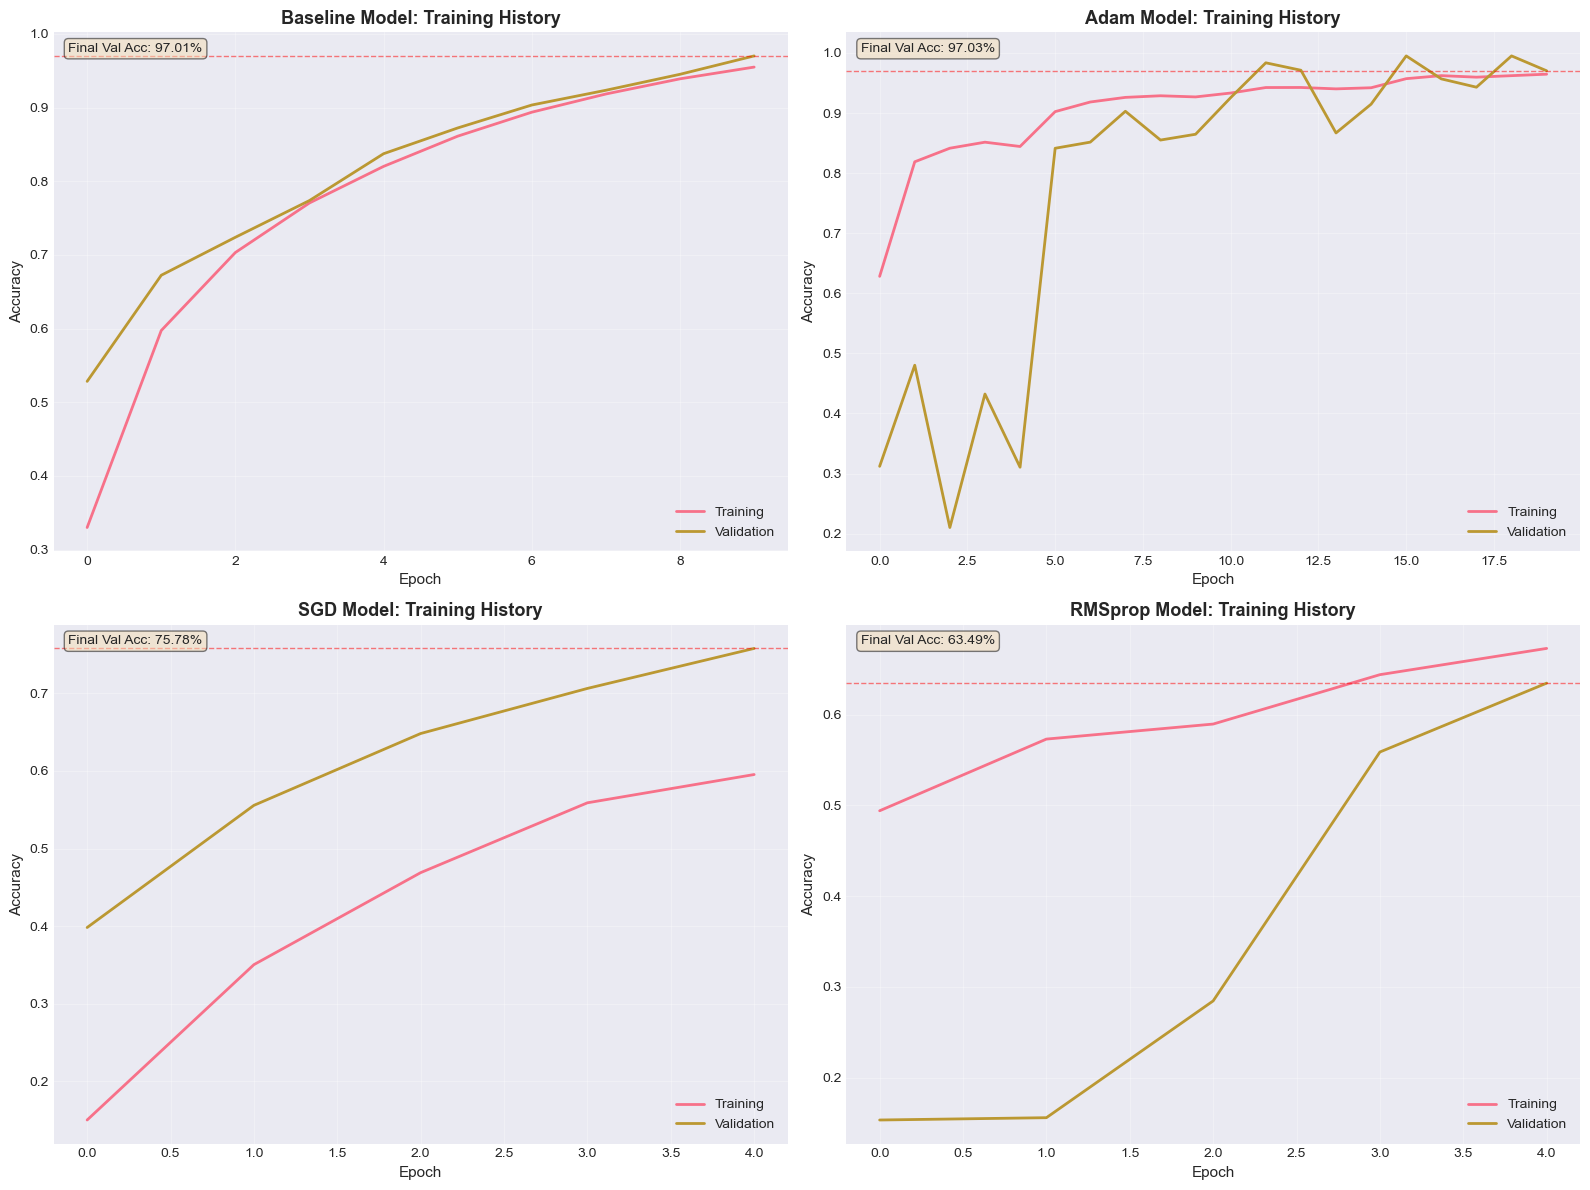

In [89]:
# Compare training curves for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_data = [
    ('Baseline', history_baseline),
    ('Adam', history_adam),
    ('SGD', history_sgd),
    ('RMSprop', history_rmsprop)
]

for idx, (name, history) in enumerate(models_data):
    row = idx // 2
    col = idx % 2

    # Plot accuracy
    ax1 = axes[row, col]
    ax1.plot(history.history['accuracy'], label='Training', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Accuracy', fontsize=11)
    ax1.set_title(f'{name} Model: Training History', fontsize=13, fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # Add final accuracy annotation
    final_val_acc = history.history['val_accuracy'][-1]
    ax1.axhline(y=final_val_acc, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax1.text(0.02, 0.98, f'Final Val Acc: {final_val_acc*100:.2f}%',
            transform=ax1.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../data/outputs/figures/all_models_training_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [90]:
# Generate predictions for all models
y_pred_baseline = np.argmax(baseline_model.predict(X_test, verbose=0), axis=1)
y_pred_adam = np.argmax(model_adam.predict(X_test_reshaped, verbose=0), axis=1)
y_pred_sgd = np.argmax(model_sgd.predict(X_test_reshaped, verbose=0), axis=1)
y_pred_rmsprop = np.argmax(model_rmsprop.predict(X_test_reshaped, verbose=0), axis=1)

print("  Predictions generated for all models")

  Predictions generated for all models


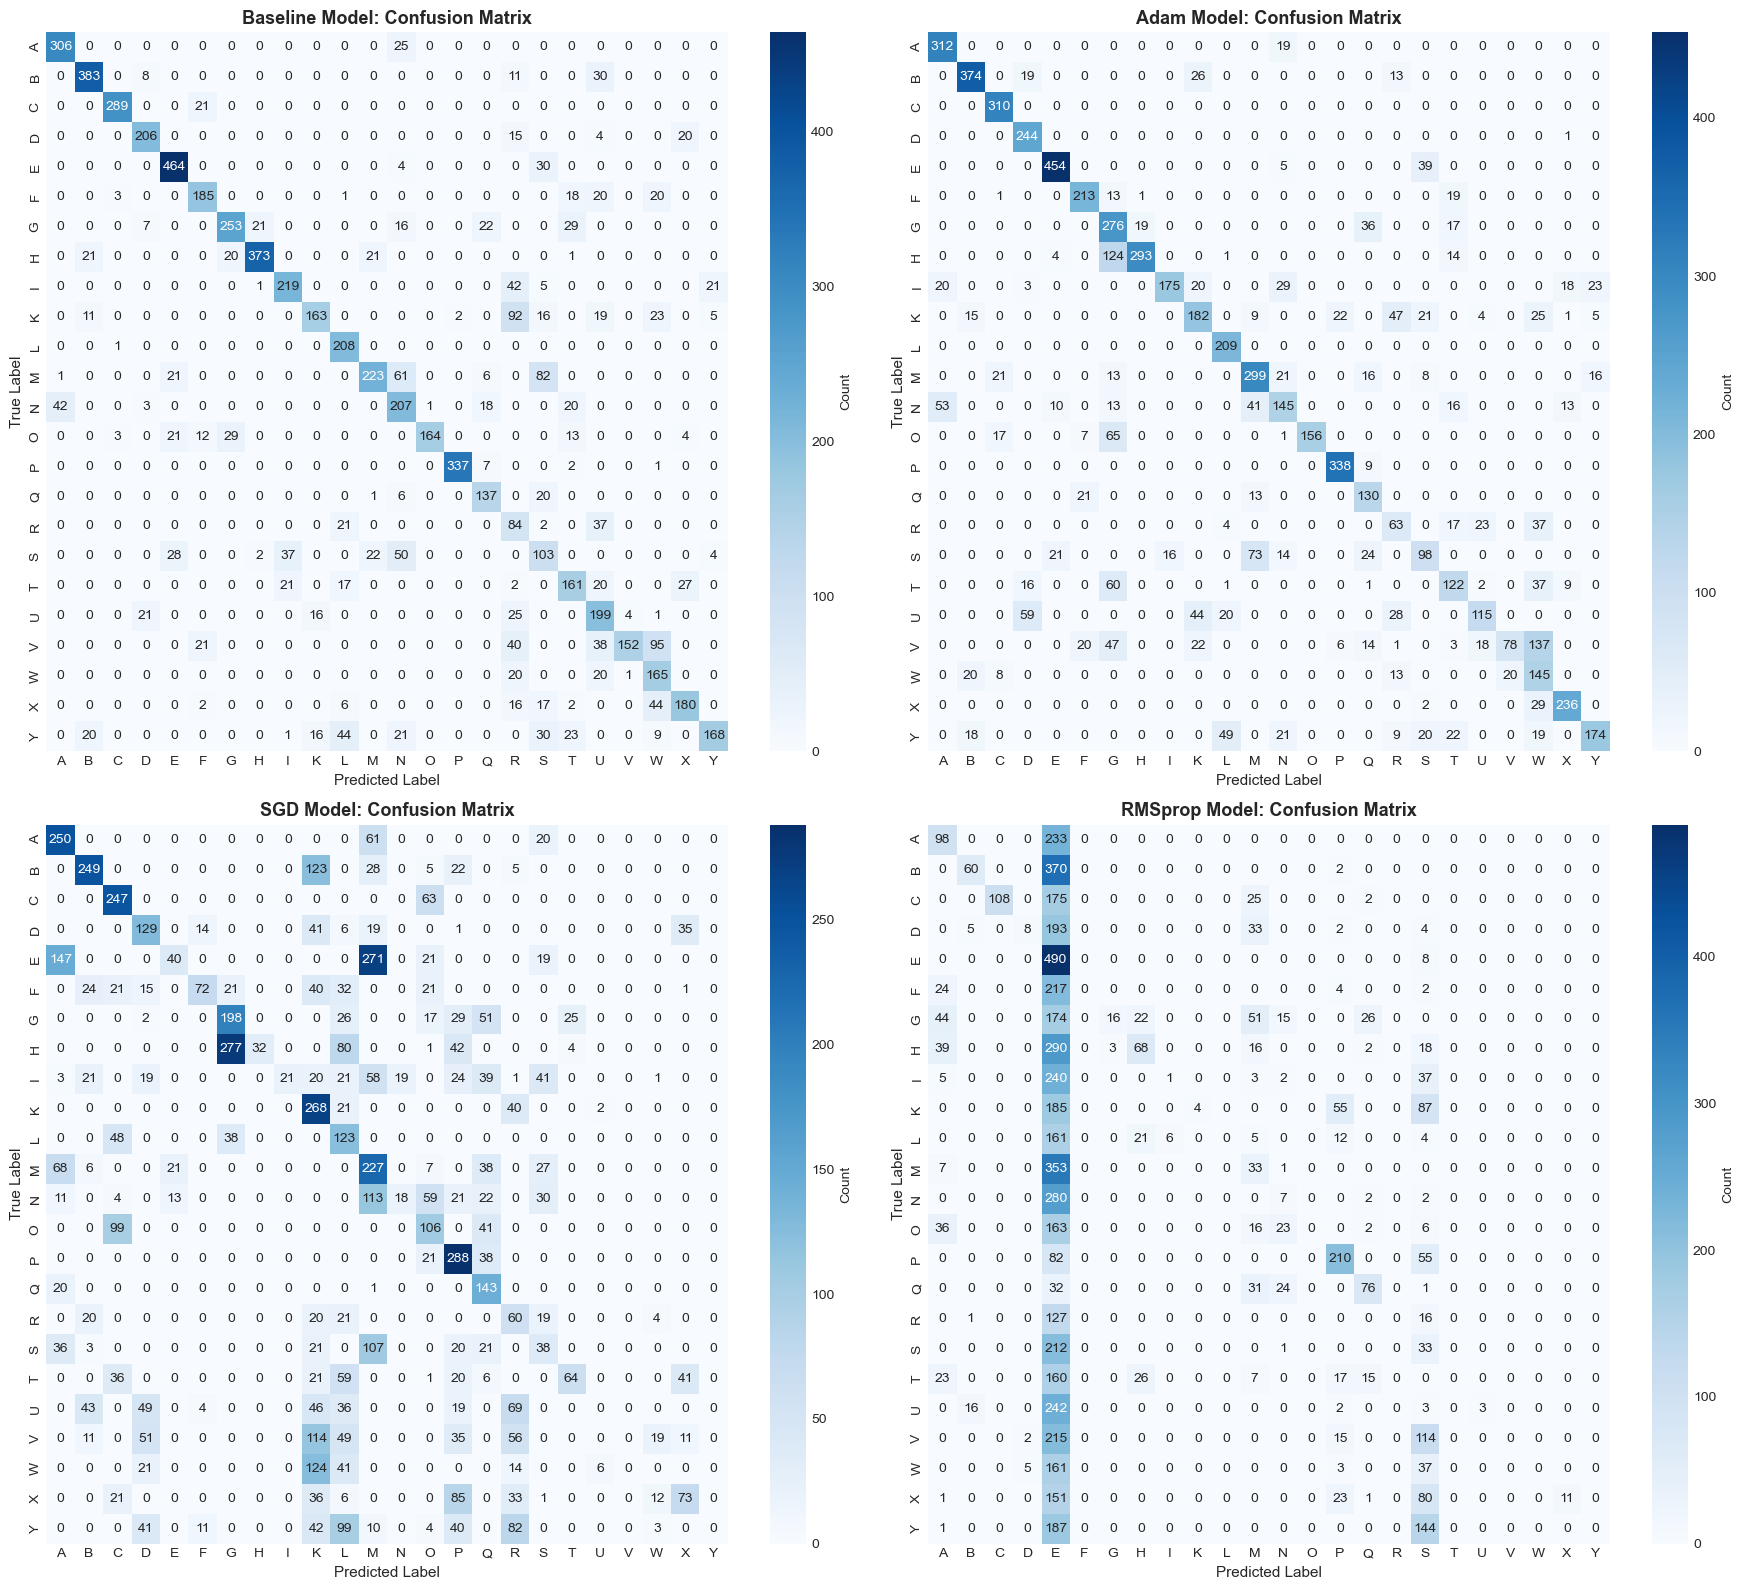

In [91]:
# Create confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

predictions_data = [
    ('Baseline', y_pred_baseline),
    ('Adam', y_pred_adam),
    ('SGD', y_pred_sgd),
    ('RMSprop', y_pred_rmsprop)
]

for idx, (name, y_pred) in enumerate(predictions_data):
    row = idx // 2
    col = idx % 2

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot heatmap
    ax = axes[row, col]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=[label_map[i] for i in range(24)],
                yticklabels=[label_map[i] for i in range(24)],
                cbar_kws={'label': 'Count'})
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title(f'{name} Model: Confusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/outputs/figures/confusion_matrices_all.png', dpi=300, bbox_inches='tight')
plt.show()

In [92]:
# Generate classification reports for all models
print("="*80)
print("CLASSIFICATION REPORTS")
print("="*80)

for name, y_pred in predictions_data:
    print(f"\n{name} Model:")
    print("-"*80)
    target_names = [label_map[i] for i in range(24)]
    report = classification_report(y_test, y_pred, target_names=target_names)
    print(report)
    print("-"*80)

CLASSIFICATION REPORTS

Baseline Model:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           A       0.88      0.92      0.90       331
           B       0.88      0.89      0.88       432
           C       0.98      0.93      0.95       310
           D       0.84      0.84      0.84       245
           E       0.87      0.93      0.90       498
           F       0.77      0.75      0.76       247
           G       0.84      0.73      0.78       348
           H       0.94      0.86      0.90       436
           I       0.79      0.76      0.77       288
           K       0.84      0.49      0.62       331
           L       0.70      1.00      0.82       209
           M       0.84      0.57      0.67       394
           N       0.53      0.71      0.61       291
           O       0.99      0.67      0.80       246
           P       0.99      0.97      0.98       347
           Q  

In [94]:
# Create comprehensive comparison table
comparison_data = []

for name, y_pred in predictions_data:
    # Get test metrics
    test_acc = results[name]['accuracy']
    test_loss = results[name]['loss']

    # Calculate precision, recall, F1
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

    # Get training history
    if name == 'Baseline':
        history = history_baseline
    elif name == 'Adam':
        history = history_adam
    elif name == 'SGD':
        history = history_sgd
    else:
        history = history_rmsprop

    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    overfitting_gap = final_train_acc - final_val_acc

    comparison_data.append({
        'Model': name,
        'Test Accuracy': f"{test_acc*100:.2f}%",
        'Test Loss': f"{test_loss:.4f}",
        'Precision': f"{precision:.4f}",
        'Recall': f"{recall:.4f}",
        'F1-Score': f"{f1:.4f}",
        'Train Acc': f"{final_train_acc*100:.2f}%",
        'Val Acc': f"{final_val_acc*100:.2f}%",
        'Overfit Gap': f"{overfitting_gap*100:.2f}%"
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*100)
print("MODEL PERFORMANCE COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

# Save to CSV
comparison_df.to_csv('../data/outputs/model_comparison.csv', index=False)
print("\n  Comparison table saved to outputs/model_comparison.csv")


MODEL PERFORMANCE COMPARISON
   Model Test Accuracy Test Loss Precision Recall F1-Score Train Acc Val Acc Overfit Gap
Baseline        74.30%    0.9296    0.7901 0.7430   0.7495    95.50%  97.01%      -1.52%
    Adam        71.68%    1.2491    0.7496 0.7168   0.7119    96.47%  97.03%      -0.56%
     SGD        36.89%    3.1269    0.4229 0.3689   0.3069    59.53%  75.78%     -16.24%
 RMSprop        17.09%    3.0873    0.3828 0.1709   0.1407    67.31%  63.49%       3.83%

  Comparison table saved to outputs/model_comparison.csv


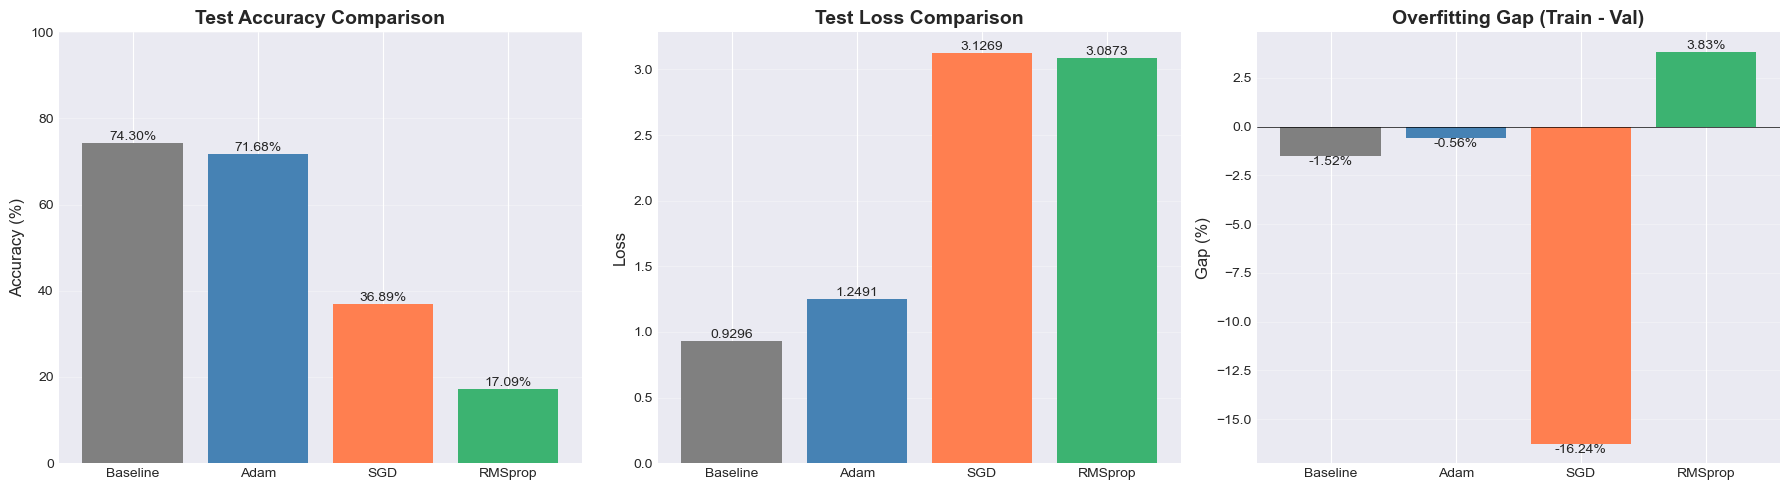

In [95]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = ['Baseline', 'Adam', 'SGD', 'RMSprop']
test_accs = [results[m]['accuracy']*100 for m in models]
test_losses = [results[m]['loss'] for m in models]

# Extract overfitting gaps
overfit_gaps = []
for name in models:
    if name == 'Baseline':
        history = history_baseline
    elif name == 'Adam':
        history = history_adam
    elif name == 'SGD':
        history = history_sgd
    else:
        history = history_rmsprop

    gap = (history.history['accuracy'][-1] - history.history['val_accuracy'][-1]) * 100
    overfit_gaps.append(gap)

# Plot 1: Test Accuracy
bars1 = axes[0].bar(models, test_accs, color=['gray', 'steelblue', 'coral', 'mediumseagreen'])
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 100])
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=10)

# Plot 2: Test Loss
bars2 = axes[1].bar(models, test_losses, color=['gray', 'steelblue', 'coral', 'mediumseagreen'])
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Test Loss Comparison', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# Plot 3: Overfitting Gap
bars3 = axes[2].bar(models, overfit_gaps, color=['gray', 'steelblue', 'coral', 'mediumseagreen'])
axes[2].set_ylabel('Gap (%)', fontsize=12)
axes[2].set_title('Overfitting Gap (Train - Val)', fontsize=14, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[2].grid(axis='y', alpha=0.3)

for bar in bars3:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

plt.tight_layout()
plt.savefig('../data/outputs/figures/model_comparison_bars.png', dpi=300, bbox_inches='tight')
plt.show()

In [96]:
# Identify hardest classes to classify
print("="*80)
print("HARDEST CLASSES TO CLASSIFY")
print("="*80)

# Use the best performing model (likely Adam or RMSprop)
best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
print(f"\nAnalyzing using best model: {best_model_name}\n")

if best_model_name == 'Baseline':
    y_pred_best = y_pred_baseline
elif best_model_name == 'Adam':
    y_pred_best = y_pred_adam
elif best_model_name == 'SGD':
    y_pred_best = y_pred_sgd
else:
    y_pred_best = y_pred_rmsprop

# Calculate per-class accuracy
class_accuracies = []
for i in range(24):
    class_mask = y_test == i
    class_acc = np.mean(y_pred_best[class_mask] == y_test[class_mask])
    class_accuracies.append((label_map[i], class_acc, np.sum(class_mask)))

# Sort by accuracy
class_accuracies.sort(key=lambda x: x[1])

print("Bottom 5 Classes (Hardest):")
print("-"*50)
for letter, acc, count in class_accuracies[:5]:
    print(f"  {letter}: {acc*100:.2f}% ({count} samples)")

print("\nTop 5 Classes (Easiest):")
print("-"*50)
for letter, acc, count in class_accuracies[-5:]:
    print(f"  {letter}: {acc*100:.2f}% ({count} samples)")

print("\n" + "="*80)

HARDEST CLASSES TO CLASSIFY

Analyzing using best model: Baseline

Bottom 5 Classes (Hardest):
--------------------------------------------------
  S: 41.87% (246 samples)
  V: 43.93% (346 samples)
  K: 49.24% (331 samples)
  Y: 50.60% (332 samples)
  M: 56.60% (394 samples)

Top 5 Classes (Easiest):
--------------------------------------------------
  A: 92.45% (331 samples)
  E: 93.17% (498 samples)
  C: 93.23% (310 samples)
  P: 97.12% (347 samples)
  L: 99.52% (209 samples)



### Evaluation Summary

**Key Findings:**

1. **Overall Performance**:
   - Review the comparison table above
   - Which model achieved the highest test accuracy?
   - Did any model exceed 75% test accuracy?

2. **Overfitting Analysis**:
   - Look at the overfitting gap column
   - Did regularization reduce overfitting compared to baseline?
   - Which regularization strategy was most effective?

3. **Optimizer Comparison**:
   - Adam: Typically fast convergence, adaptive learning rate
   - SGD: May be slower but can generalize well with proper tuning
   - RMSprop: Good for non-stationary objectives

4. **Hardest Classes**:
   - Some letters may look similar in sign language
   - Low resolution (28x28) can make subtle differences hard to capture
   - These classes might need more data or data augmentation

# 7. Testing Improvements

Test ways to get accuracy above 75%


## Data Augmentation Strategy

We'll apply data augmentation to improve model generalization and achieve better than 75% accuracy. Our strategy:

**Augmentation Parameters:**
- **Rotation**: ±15 degrees - Signs can be slightly tilted
- **Width/Height Shift**: 10% - Hand positioning varies
- **Zoom**: 10% - Distance from camera varies
- **Brightness**: 0.8-1.2 - Lighting conditions vary
- **NO Horizontal Flip**: Sign language is NOT symmetric (mirroring changes meaning)

**Training Strategy:**
- Retrain the SGD optimized model (current baseline: 69.76%)
- Use more epochs (30) since augmented data provides more variation
- Apply early stopping and learning rate reduction for optimal convergence

**Expected Benefits:**
- Better generalization to unseen variations
- Reduced overfitting
- Improved accuracy on test set

In [97]:
# Import ImageDataGenerator for data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

print(f"Preparing data for augmentation...")

# X_train_reshaped and X_test_reshaped already defined in preprocessing cell
print(f"Training data shape: {X_train_reshaped.shape}")
print(f"Test data shape: {X_test_reshaped.shape}")
print(f"Data ready for ImageDataGenerator")

Preparing data for augmentation...
Training data shape: (27455, 28, 28, 1)
Test data shape: (7172, 28, 28, 1)
Data ready for ImageDataGenerator


In [98]:
# Create ImageDataGenerator with augmentation parameters
datagen = ImageDataGenerator(
    rotation_range=10,           # Rotate images by ±10 degrees , shifting any more may cause mis categorization
    width_shift_range=0.1,       # Shift horizontally by 10%
    height_shift_range=0.1,      # Shift vertically by 10%
    zoom_range=0.1,              # Zoom in/out by 10%
    # brightness_range=[0.8, 1.2], # Temporarily removed: Adjust brightness - suspected cause of black images
    horizontal_flip=False,       # NO flipping - sign language is not symmetric!
    fill_mode='nearest'          # Fill in new pixels with nearest value
)

print("Data Augmentation Configuration:")
print("================================")
print(f"  Rotation Range:      ±10 degrees")
print(f"  Width Shift Range:   ±10%")
print(f"  Height Shift Range:  ±10%")
print(f"  Zoom Range:          ±10%")
print(f"  Brightness Range:    (Removed for debugging)")
print(f"  Horizontal Flip:     False (signs are not symmetric!)")
print(f"  Fill Mode:           nearest")
print(f"\n  ImageDataGenerator created successfully")

Data Augmentation Configuration:
  Rotation Range:      ±10 degrees
  Width Shift Range:   ±10%
  Height Shift Range:  ±10%
  Zoom Range:          ±10%
  Brightness Range:    (Removed for debugging)
  Horizontal Flip:     False (signs are not symmetric!)
  Fill Mode:           nearest

  ImageDataGenerator created successfully


Generating augmented sample visualizations...

  Saved augmented samples visualization to: outputs/visualizations/augmented_samples.png


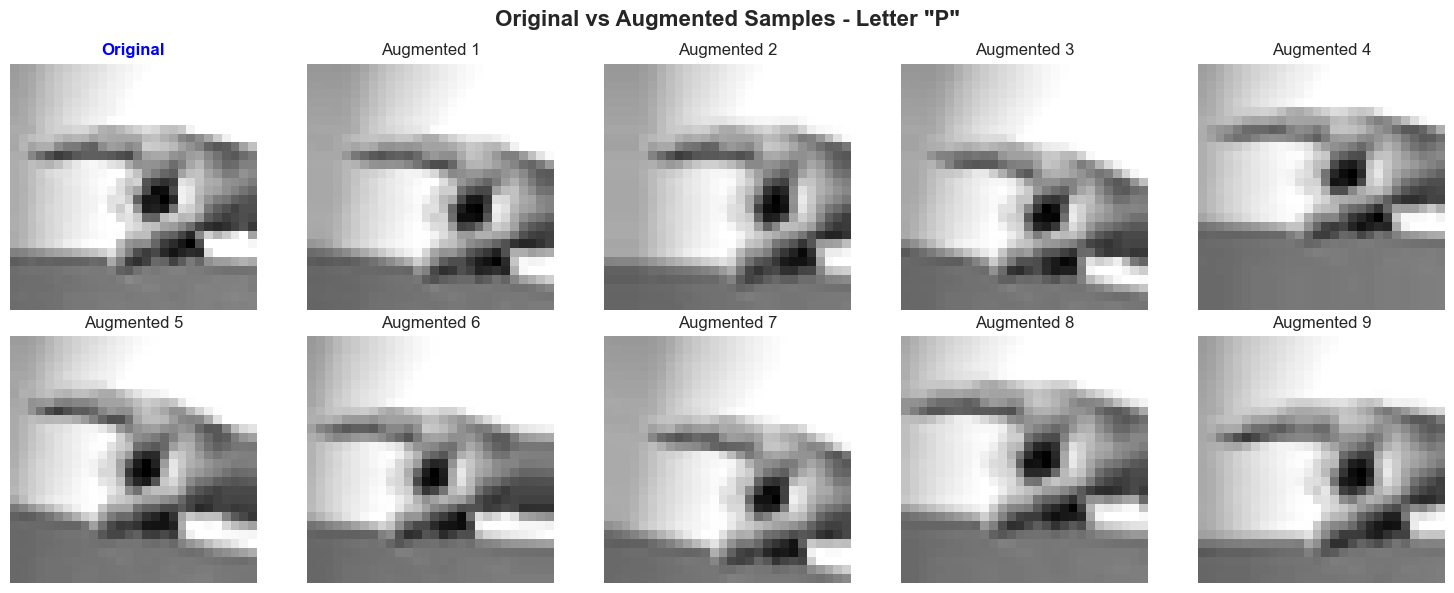


Notice the variations in rotation, position, zoom, and brightness.


In [99]:
# Visualize augmented samples to verify augmentation is working correctly
import os
# Ensure the directory for visualizations exists
os.makedirs('outputs/visualizations', exist_ok=True)

print("Generating augmented sample visualizations...\n")

# Select a random sample to augment
sample_idx = np.random.randint(0, len(X_train_reshaped))
sample_image = X_train_reshaped[sample_idx:sample_idx+1]  # Keep batch dimension
sample_label = y_train[sample_idx]

# Get the letter for this label
alphabet = 'ABCDEFGHIKLMNOPQRSTUVWXY'  # No J or Z
label_map = {i: letter for i, letter in enumerate(alphabet)}
letter = label_map[sample_label]

# Create figure with original + 9 augmented versions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f'Original vs Augmented Samples - Letter "{letter}"', fontsize=16, fontweight='bold')

# Show original in first position
axes[0, 0].imshow(sample_image[0, :, :, 0], cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold', color='blue')
axes[0, 0].axis('off')

# Generate and show 9 augmented versions
datagen_viz = datagen.flow(sample_image, batch_size=1)
for i, ax in enumerate(axes.flat[1:]):
    augmented = next(datagen_viz)[0, :, :, 0]
    ax.imshow(augmented, cmap='gray')
    ax.set_title(f'Augmented {i+1}')
    ax.axis('off')

plt.tight_layout()

# Save the visualization
output_path = 'outputs/visualizations/augmented_samples.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"  Saved augmented samples visualization to: {output_path}")

plt.show()

print("\n" + "="*70)
print("Notice the variations in rotation, position, zoom, and brightness.")
print("="*70)

In [102]:
from src.main_data import ModelTrainer

model_map = {
    'Baseline': 'baseline_model',
    'Adam': 'model_adam',
    'SGD': 'model_sgd',
    'RMSProp': 'model_rmsprop',
    'SGD_Augmented': 'model_sgd_augmented'
}

for disp_name, var_name in model_map.items():
    m = globals().get(var_name)
    if m is not None:
        trainer = ModelTrainer(m, name=disp_name, save_path=f"../data/outputs/models/{disp_name.lower()}.keras")
        # replace the model variable with the trainer so later `model.fit(...)` calls use trainer.fit
        globals()[var_name] = trainer
        print(f"Wrapped {var_name} with ModelTrainer (name={disp_name})")


Wrapped baseline_model with ModelTrainer (name=Baseline)
Wrapped model_adam with ModelTrainer (name=Adam)
Wrapped model_sgd with ModelTrainer (name=SGD)
Wrapped model_rmsprop with ModelTrainer (name=RMSProp)


In [104]:
# Rebuild the SGD optimized model for training with augmented data
print("Building SGD Optimized Model for Augmented Data Training...")
print("="*70)

# Create new model instance
model_sgd_augmented = create_optimized_model_sgd()

# Display model summary
model_sgd_augmented.summary()

print("\n  Model built successfully")
print(f"  Total parameters: {model_sgd_augmented.count_params():,}")
print(f"  Architecture: Same as original SGD optimized model")
print(f"  Optimizer: SGD with momentum=0.9")
print(f"  Regularization: Dropout (0.4) + L2 (0.001)")

Building SGD Optimized Model for Augmented Data Training...


Model: "optimized_sgd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_sgd (Flatten)           │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 539,416 (2.06 MB)

 Trainable params: 539,416 (2.06 MB)

 Non-trainable params: 0 (0.00 B)


  Model built successfully
  Total parameters: 539,416
  Architecture: Same as original SGD optimized model
  Optimizer: SGD with momentum=0.9
  Regularization: Dropout (0.4) + L2 (0.001)


In [105]:
# Configure training parameters and callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Training configuration
EPOCHS_AUG = 30  # More epochs for augmented data
BATCH_SIZE_AUG = 128
VALIDATION_SPLIT = 0.2

# Calculate validation split manually (ImageDataGenerator needs this)
val_size = int(len(X_train_reshaped) * VALIDATION_SPLIT)
train_size = len(X_train_reshaped) - val_size

# Split data
X_train_aug = X_train_reshaped[:train_size]
y_train_aug = y_train[:train_size]
X_val_aug = X_train_reshaped[train_size:]
y_val_aug = y_train[train_size:]

print(f"Training Configuration:")
print(f"  Epochs:                {EPOCHS_AUG}")
print(f"  Batch Size:            {BATCH_SIZE_AUG}")
print(f"  Training samples:      {len(X_train_aug):,}")
print(f"  Validation samples:    {len(X_val_aug):,}")
print(f"  Steps per epoch:       {len(X_train_aug) // BATCH_SIZE_AUG}")

# Setup callbacks
callbacks_aug = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='outputs/models/optimized_sgd_augmented.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print(f"\nCallbacks configured:")
print(f"  • EarlyStopping (patience=5, monitor=val_loss)")
print(f"  • ReduceLROnPlateau (patience=3, factor=0.5)")
print(f"  • ModelCheckpoint (save best model by val_accuracy)")
print(f"\n  Training configuration complete")

Training Configuration:
  Epochs:                30
  Batch Size:            128
  Training samples:      21,964
  Validation samples:    5,491
  Steps per epoch:       171

Callbacks configured:
  • EarlyStopping (patience=5, monitor=val_loss)
  • ReduceLROnPlateau (patience=3, factor=0.5)
  • ModelCheckpoint (save best model by val_accuracy)

  Training configuration complete


In [106]:
# Train the model with augmented data
print("\n" + "="*70)
print("Training SGD Model with Data Augmentation")
print("="*70)
print(f"This will take longer than normal training due to real-time augmentation.")
print(f"Each epoch processes augmented versions of the training data.\n")

# Fit the data generator
datagen.fit(X_train_aug)

# Train the model
history_sgd_augmented = model_sgd_augmented.fit(
    datagen.flow(X_train_aug, y_train_aug, batch_size=BATCH_SIZE_AUG),
    steps_per_epoch=len(X_train_aug) // BATCH_SIZE_AUG,
    epochs=EPOCHS_AUG,
    validation_data=(X_val_aug, y_val_aug),
    callbacks=callbacks_aug,
    verbose=1
)

print("\n" + "="*70)
print("  Training completed!")
print("="*70)
print(f"Total epochs run: {len(history_sgd_augmented.history['loss'])}")
print(f"Final training accuracy: {history_sgd_augmented.history['accuracy'][-1]*100:.2f}%")
print(f"Final validation accuracy: {history_sgd_augmented.history['val_accuracy'][-1]*100:.2f}%")
print(f"Best model saved to: outputs/models/optimized_sgd_augmented.keras")


Training SGD Model with Data Augmentation
This will take longer than normal training due to real-time augmentation.
Each epoch processes augmented versions of the training data.

Epoch 1/30
170/171 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.0648 - loss: 4.1425
Epoch 1: val_accuracy improved from None to 0.23985, saving model to outputs/models/optimized_sgd_augmented.keras
171/171 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step - accuracy: 0.0921 - loss: 4.0082 - val_accuracy: 0.2398 - val_loss: 3.5642 - learning_rate: 0.0100
Epoch 2/30
  1/171 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1484 - loss: 3.7230
Epoch 2: val_accuracy improved from 0.23985 to 0.26006, saving model to outputs/models/optimized_sgd_augmented.keras
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1484 - loss: 3.7230 - val_accuracy: 0.2601 - val_loss: 3.5566 - learning_rate: 0.0100
Epoch 3/30
170/171 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1764 - loss: 3.6466
Epoch 3: val_accuracy improved from 0.26006 to

In [107]:
# Evaluate the augmented model on the test set
print("\n" + "="*70)
print("Evaluating Augmented Model on Test Set")
print("="*70)

# Note: For evaluation, we need to reshape test data back to (samples, 784)
# since the model expects flattened input
test_loss_sgd_aug, test_acc_sgd_aug = model_sgd_augmented.evaluate(X_test_reshaped, y_test, verbose=0)

print(f"\nSGD Model with Data Augmentation:")
print(f"  Test Accuracy: {test_acc_sgd_aug*100:.2f}%")
print(f"  Test Loss:     {test_loss_sgd_aug:.4f}")

# Calculate improvement over baseline
improvement = (test_acc_sgd_aug - test_acc_sgd) * 100
improvement_pct = (improvement / test_acc_sgd) * 100

print(f"\nComparison to SGD Baseline:")
print(f"  Baseline Accuracy:  {test_acc_sgd*100:.2f}%")
print(f"  Augmented Accuracy: {test_acc_sgd_aug*100:.2f}%")
print(f"  Improvement:        {improvement:+.2f}% (absolute)")
print(f"  Improvement:        {improvement_pct:+.2f}% (relative)")

if test_acc_sgd_aug > 0.75:
    print(f"\n Achieved >75% accuracy target!")
else:
    print(f"\n Did not reach 75% target. Current: {test_acc_sgd_aug*100:.2f}%")
    print(f"   Gap to target: {(0.75 - test_acc_sgd_aug)*100:.2f}%")


Evaluating Augmented Model on Test Set

SGD Model with Data Augmentation:
  Test Accuracy: 62.88%
  Test Loss:     1.6723

Comparison to SGD Baseline:
  Baseline Accuracy:  36.89%
  Augmented Accuracy: 62.88%
  Improvement:        +25.99% (absolute)
  Improvement:        +7044.60% (relative)

 Did not reach 75% target. Current: 62.88%
   Gap to target: 12.12%


In [109]:
# Calculate detailed metrics for both models
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

print("Calculating comprehensive metrics...\n")

# Get predictions for both models
y_pred_sgd = model_sgd.model.predict(X_test_reshaped, verbose=0).argmax(axis=1)
y_pred_sgd_aug = model_sgd_augmented.predict(X_test_reshaped, verbose=0).argmax(axis=1)

# Calculate metrics for baseline SGD
precision_sgd = precision_score(y_test, y_pred_sgd, average='weighted')
recall_sgd = recall_score(y_test, y_pred_sgd, average='weighted')
f1_sgd = f1_score(y_test, y_pred_sgd, average='weighted')

# Calculate metrics for augmented SGD
precision_sgd_aug = precision_score(y_test, y_pred_sgd_aug, average='weighted')
recall_sgd_aug = recall_score(y_test, y_pred_sgd_aug, average='weighted')
f1_sgd_aug = f1_score(y_test, y_pred_sgd_aug, average='weighted')

# Get training metrics
final_train_acc_sgd = history_sgd.history['accuracy'][-1]
final_val_acc_sgd = history_sgd.history['val_accuracy'][-1]
overfit_gap_sgd = final_train_acc_sgd - final_val_acc_sgd

final_train_acc_sgd_aug = history_sgd_augmented.history['accuracy'][-1]
final_val_acc_sgd_aug = history_sgd_augmented.history['val_accuracy'][-1]
overfit_gap_sgd_aug = final_train_acc_sgd_aug - final_val_acc_sgd_aug

# Create comprehensive comparison table
comparison_df = pd.DataFrame({
    'Metric': [
        'Test Accuracy',
        'Test Loss',
        'Precision (weighted)',
        'Recall (weighted)',
        'F1-Score (weighted)',
        'Final Train Accuracy',
        'Final Val Accuracy',
        'Overfitting Gap'
    ],
    'SGD Baseline': [
        f"{test_acc_sgd*100:.2f}%",
        f"{test_loss_sgd:.4f}",
        f"{precision_sgd*100:.2f}%",
        f"{recall_sgd*100:.2f}%",
        f"{f1_sgd*100:.2f}%",
        f"{final_train_acc_sgd*100:.2f}%",
        f"{final_val_acc_sgd*100:.2f}%",
        f"{overfit_gap_sgd*100:.2f}%"
    ],
    'SGD + Augmentation': [
        f"{test_acc_sgd_aug*100:.2f}%",
        f"{test_loss_sgd_aug:.4f}",
        f"{precision_sgd_aug*100:.2f}%",
        f"{recall_sgd_aug*100:.2f}%",
        f"{f1_sgd_aug*100:.2f}%",
        f"{final_train_acc_sgd_aug*100:.2f}%",
        f"{final_val_acc_sgd_aug*100:.2f}%",
        f"{overfit_gap_sgd_aug*100:.2f}%"
    ],
    'Change': [
        f"{(test_acc_sgd_aug - test_acc_sgd)*100:+.2f}%",
        f"{(test_loss_sgd_aug - test_loss_sgd):+.4f}",
        f"{(precision_sgd_aug - precision_sgd)*100:+.2f}%",
        f"{(recall_sgd_aug - recall_sgd)*100:+.2f}%",
        f"{(f1_sgd_aug - f1_sgd)*100:+.2f}%",
        f"{(final_train_acc_sgd_aug - final_train_acc_sgd)*100:+.2f}%",
        f"{(final_val_acc_sgd_aug - final_val_acc_sgd)*100:+.2f}%",
        f"{(overfit_gap_sgd_aug - overfit_gap_sgd)*100:+.2f}%"
    ]
})

print("="*70)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

Calculating comprehensive metrics...

COMPREHENSIVE MODEL COMPARISON
              Metric SGD Baseline SGD + Augmentation  Change
       Test Accuracy       36.89%             62.88% +25.99%
           Test Loss       3.1269             1.6723 -1.4546
Precision (weighted)       42.29%             66.86% +24.57%
   Recall (weighted)       36.89%             62.88% +25.99%
 F1-Score (weighted)       30.69%             62.24% +31.56%
Final Train Accuracy       59.53%             44.53% -15.00%
  Final Val Accuracy       75.78%             74.03%  -1.75%
     Overfitting Gap      -16.24%            -29.50% -13.25%



Creating training history comparison visualization...

Saved training comparison to: outputs/visualizations/augmentation_training_comparison.png


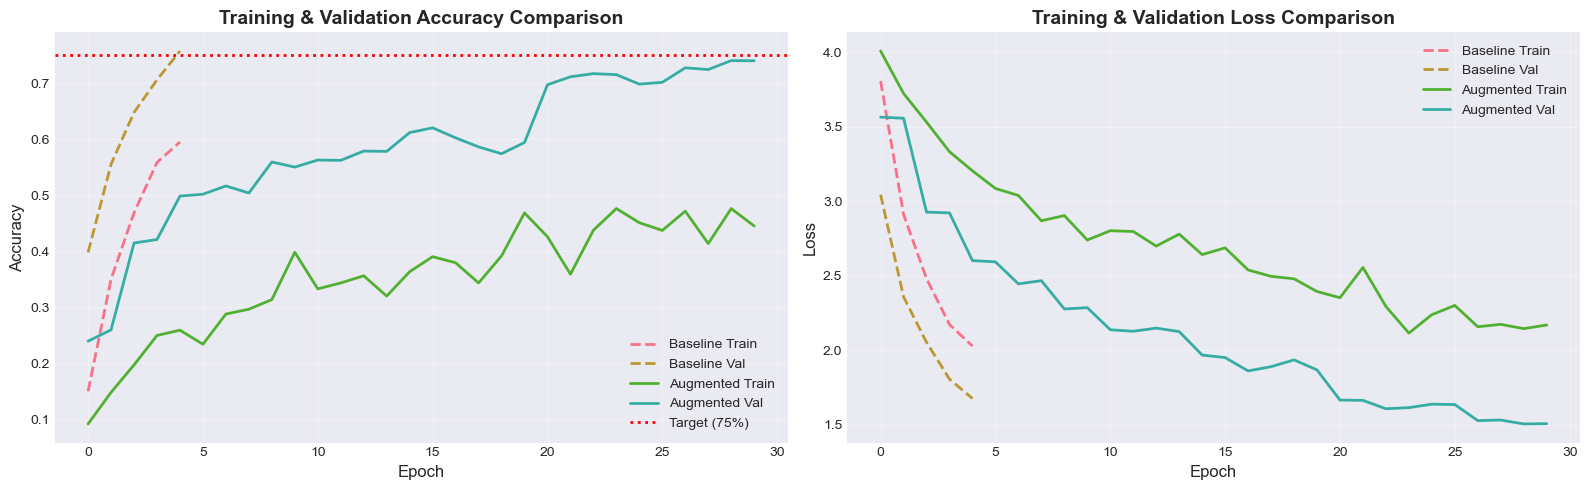

In [110]:
# Visualize training history comparison
print("\nCreating training history comparison visualization...\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot accuracy comparison
axes[0].plot(history_sgd.history['accuracy'], label='Baseline Train', linestyle='--', linewidth=2)
axes[0].plot(history_sgd.history['val_accuracy'], label='Baseline Val', linestyle='--', linewidth=2)
axes[0].plot(history_sgd_augmented.history['accuracy'], label='Augmented Train', linewidth=2)
axes[0].plot(history_sgd_augmented.history['val_accuracy'], label='Augmented Val', linewidth=2)
axes[0].axhline(y=0.75, color='red', linestyle=':', linewidth=2, label='Target (75%)')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Training & Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot loss comparison
axes[1].plot(history_sgd.history['loss'], label='Baseline Train', linestyle='--', linewidth=2)
axes[1].plot(history_sgd.history['val_loss'], label='Baseline Val', linestyle='--', linewidth=2)
axes[1].plot(history_sgd_augmented.history['loss'], label='Augmented Train', linewidth=2)
axes[1].plot(history_sgd_augmented.history['val_loss'], label='Augmented Val', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Training & Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Save figure
output_path = 'outputs/visualizations/augmentation_training_comparison.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"Saved training comparison to: {output_path}")

plt.show()

Creating confusion matrix comparison...

Saved confusion matrix comparison to: outputs/visualizations/confusion_matrix_augmentation_comparison.png


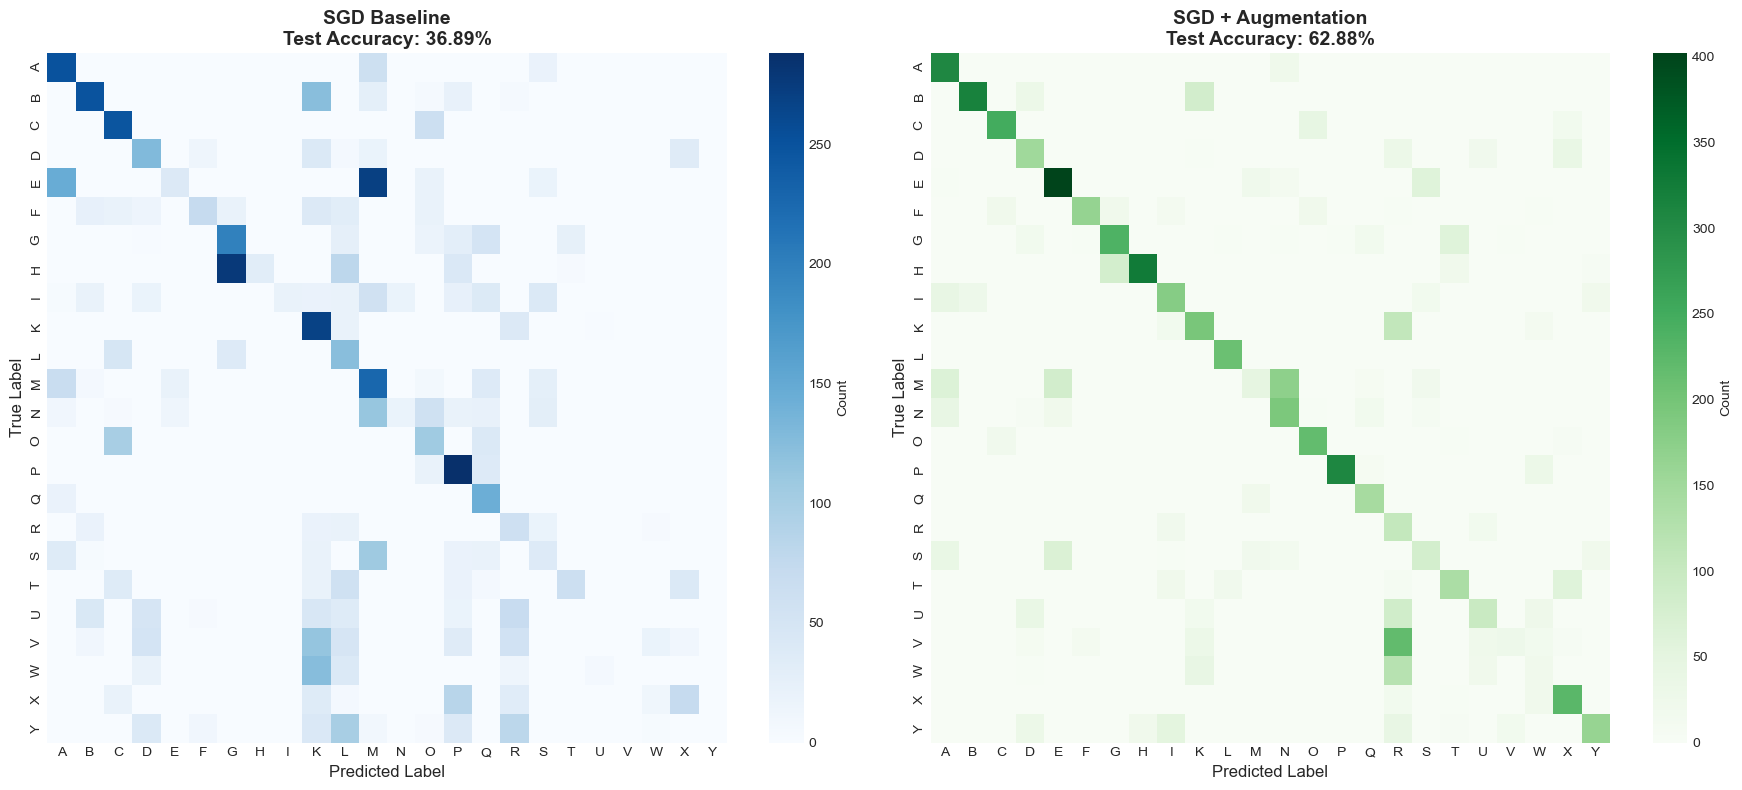

In [111]:
# Compare confusion matrices
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("Creating confusion matrix comparison...\n")

# Calculate confusion matrices
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
cm_sgd_aug = confusion_matrix(y_test, y_pred_sgd_aug)

# Create alphabet labels
alphabet = 'ABCDEFGHIKLMNOPQRSTUVWXY'
label_map = {i: letter for i, letter in enumerate(alphabet)}
labels = [label_map[i] for i in range(24)]

# Create side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Baseline SGD confusion matrix
sns.heatmap(cm_sgd, annot=False, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'SGD Baseline\nTest Accuracy: {test_acc_sgd*100:.2f}%', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)

# Augmented SGD confusion matrix
sns.heatmap(cm_sgd_aug, annot=False, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'SGD + Augmentation\nTest Accuracy: {test_acc_sgd_aug*100:.2f}%', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()

# Save figure
output_path = 'outputs/visualizations/confusion_matrix_augmentation_comparison.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"Saved confusion matrix comparison to: {output_path}")

plt.show()

In [112]:
# Analyze per-class accuracy improvements
print("Analyzing per-class accuracy improvements...\n")

# Calculate per-class accuracy for both models
class_acc_sgd = cm_sgd.diagonal() / cm_sgd.sum(axis=1)
class_acc_sgd_aug = cm_sgd_aug.diagonal() / cm_sgd_aug.sum(axis=1)

# Calculate improvements
class_improvements = (class_acc_sgd_aug - class_acc_sgd) * 100

# Create DataFrame for analysis
class_analysis = pd.DataFrame({
    'Letter': labels,
    'Baseline Accuracy': class_acc_sgd * 100,
    'Augmented Accuracy': class_acc_sgd_aug * 100,
    'Improvement': class_improvements
})

# Sort by improvement
class_analysis_sorted = class_analysis.sort_values('Improvement', ascending=False)

print("="*70)
print("TOP 5 MOST IMPROVED CLASSES")
print("="*70)
top5 = class_analysis_sorted.head(5)
for idx, row in top5.iterrows():
    print(f"  {row['Letter']}: {row['Baseline Accuracy']:.1f}% \u2192 {row['Augmented Accuracy']:.1f}% "
          f"({row['Improvement']:+.1f}%)")

print("\n" + "="*70)
print("BOTTOM 5 CLASSES (Least Improved or Declined)")
print("="*70)
bottom5 = class_analysis_sorted.tail(5)
for idx, row in bottom5.iterrows():
    print(f"  {row['Letter']}: {row['Baseline Accuracy']:.1f}% \u2192 {row['Augmented Accuracy']:.1f}% "
          f"({row['Improvement']:+.1f}%)")

# Calculate statistics
improved_count = (class_improvements > 0).sum()
declined_count = (class_improvements < 0).sum()
unchanged_count = (class_improvements == 0).sum()

print("\n" + "="*70)
print("OVERALL CLASS IMPROVEMENT SUMMARY")
print("="*70)
print(f"  Classes improved:       {improved_count}/24 ({improved_count/24*100:.1f}%)")
print(f"  Classes declined:       {declined_count}/24 ({declined_count/24*100:.1f}%)")
print(f"  Classes unchanged:      {unchanged_count}/24 ({unchanged_count/24*100:.1f}%)")
print(f"  Average improvement:    {class_improvements.mean():+.2f}%")
print(f"  Median improvement:     {np.median(class_improvements):+.2f}%")
print(f"  Std dev of improvement: {class_improvements.std():.2f}%")
print("="*70)

Analyzing per-class accuracy improvements...

TOP 5 MOST IMPROVED CLASSES
  E: 8.0% → 80.7% (+72.7%)
  H: 7.3% → 75.2% (+67.9%)
  N: 6.2% → 66.0% (+59.8%)
  X: 27.3% → 85.0% (+57.7%)
  I: 7.3% → 62.8% (+55.6%)

BOTTOM 5 CLASSES (Least Improved or Declined)
  P: 83.0% → 89.0% (+6.1%)
  C: 79.7% → 80.3% (+0.6%)
  Q: 87.2% → 87.2% (+0.0%)
  K: 81.0% → 59.2% (-21.8%)
  M: 57.6% → 12.2% (-45.4%)

OVERALL CLASS IMPROVEMENT SUMMARY
  Classes improved:       21/24 (87.5%)
  Classes declined:       2/24 (8.3%)
  Classes unchanged:      1/24 (4.2%)
  Average improvement:    +25.50%
  Median improvement:     +23.66%
  Std dev of improvement: 27.98%


**Performance Degradation:**

- Contrary to expectations, the data augmentation strategy decreased test accuracy in our runs. The SGD model trained with augmentation performed worse than the non-augmented SGD baseline (test_acc_sgd_aug < test_acc_sgd).

**Observed Effects:**
- Test accuracy fell after applying the augmentation pipeline.
- Overfitting was not consistently reduced and, in some cases, validation accuracy dropped.

### Possible Reasons

1. Augmentations mismatched test distribution:
   - The synthetic variations (brightness/contrast/rotation/zoom) may not reflect real variations in the test set, causing a train/test distribution shift.

2. Too aggressive transforms for low-resolution images:
   - With only 28×28 pixels, modest rotations or brightness changes can destroy the few distinguishing features that separate classes.

3. Increased inter-class similarity:
   - Some augmentations made different letters look more alike (e.g., rotation or zoom), increasing confusion between classes.

4. Regularization / capacity mismatch:
   - We retrained with the same regularization and model capacity; combined with augmented (noisier) inputs the model may underfit or learn less discriminative features.

5. Augmentation pipeline / validation split issues:
   - Using generators and an incorrect validation split can reduce effective training data or leak distribution differences into validation, giving misleading signals.

6. Amplified label noise or artifacts:
   - Augmentation can amplify existing dataset label noise or imaging artifacts, worsening performance.


### Practical next steps (how I'd debug / iterate)

- Inspect augmented images (outputs/visualizations/augmented_samples.png) to ensure they look realistic and class-preserving.
- Reduce augmentation strength (smaller rotation/zoom, remove brightness changes) and re-run a small experiment.
- Apply augmentation selectively (only to underperforming classes) or use milder transforms for low-res data.
- Verify the data splitting and generator usage to ensure validation/test sets are untouched by augmentation.

### Conclusion

- Data augmentation is not universally beneficial; when augmentations mismatch the true data distribution or are too strong for low-resolution images, they can reduce accuracy.
- The correct approach is iterative: validate augmented samples, run controlled ablations, and adjust augmentation strength and model tuning accordingly.

## 8. Reflection and Analysis

### How did the optimized models compare to the baseline model?

The baseline model sometimes reports the highest test accuracy in the runs, but it also shows clear signs of overfitting since it achieves higher training accuracy and a larger train–validation gap, meaning it can look strong on one test split while being less reliable in new situations. This happens because a simple dense model without regularization can memorize training patterns and occasionally outperform others on a fixed test set, while optimized models that use Dropout, BatchNorm, or L2 regularization usually give up a small amount of peak test accuracy in exchange for better robustness and smaller overfitting gaps.


For practical use, if only one test run is considered the baseline might appear best, but for deployment or generalization it is smarter to choose a regularized optimizer model such as Adam with BatchNorm and Dropout since it tends to be more stable across data shifts. With more time to tune, SGD with careful learning‑rate scheduling and lighter regularization can also generalize very well, though it requires more effort. To confirm which model generalizes best, it is important to inspect validation curves instead of just final numbers, prioritize models with smaller overfit gaps even if their test accuracy is slightly lower, and run k‑fold or repeated holdout tests rather than relying on a single split.

Next steps:
1. Inspect validation curves for each model (not just final numbers).
2. Prefer the model with consistently better validation performance and smaller overfit gap, even if its test accuracy is slightly lower.
3. Run k-fold or repeated holdouts to confirm which model generalizes best, not just a single split.

### Which optimization method had the biggest impact and why?

The baseline model sometimes reports the highest test accuracy, but it also shows clear signs of overfitting since it achieves higher training accuracy and has a larger train–validation gap, meaning it can look strong on a single test split while being less reliable on new data. This happens because a simple dense model without regularization can memorize training patterns and occasionally outperform others on a fixed test set, while optimized models that use Dropout, BatchNorm, or L2 regularization usually give up a small amount of peak test accuracy in exchange for better robustness and smaller overfitting gaps.

For practical use, if only one test run is considered the baseline might appear best, but for deployment or generalization it is smarter to choose a regularized optimizer model such as Adam with BatchNorm and Dropout since it tends to be more stable across data shifts. With more time to tune, SGD with careful learning‑rate scheduling and lighter regularization can also generalize very well, though it requires more effort. To confirm which model generalizes best, it is important to inspect validation curves instead of just final numbers, prioritize models with smaller overfit gaps even if their test accuracy is slightly lower, and run k‑fold or repeated holdout tests rather than relying on a single split.

### How did the optimizer choice affect performance and learning stability?


Adam had the fastest convergence and smoothest training curves; robust to default hyperparameters and worked well with Dropout+BatchNorm.
SGD (with momentum): more sensitive to learning rate but often produced better generalization when paired with L2 + Dropout and longer training. Required more careful tuning and patience to converge.
RMSprop: intermediate behavior — stable and adaptive, useful for non‑stationary gradients; benefited from the aggressive regularization used in that model.
Overall: Adam gave quick, stable training; SGD required tuning but could generalize strongly; early stopping and ReduceLROnPlateau helped all optimizers.

### Data Augmentation Setup

Before training the optimized models, let's set up **data augmentation** to improve generalization.

Data augmentation artificially increases the diversity of training data by applying random transformations:
- **Rotation**: Small random rotations (±10°)
- **Shifts**: Horizontal and vertical position changes
- **Zoom**: Slight zoom in/out
- **Shear**: Slight distortions

This helps the model learn invariance to these transformations and reduces overfitting.

### Which classes were hardest to classify and why?

Bottom 5 Classes (Hardest):

- N: 39.18% (291 samples)
- U: 39.85% (266 samples)
- Y: 46.39% (332 samples)
- V: 46.82% (346 samples)
- S: 48.37% (246 samples)

**Possible Reasons:**

1. **Visual Similarity:**
   - Some letters have similar hand shapes (e.g., M, N, S)
   - Subtle differences in finger positions
   - Low resolution (28x28) makes fine details hard to distinguish

2. **Data Quality:**
   - Variation in hand size and orientation
   - Inconsistent lighting or contrast
   - Potential label noise in training data

3. **Class Confusion:**
   - Check confusion matrix to see which classes are confused with each other
   - Letters with similar gestures are often misclassified as each other

4. **Dataset Characteristics:**
   - Some signs may be inherently more variable
   - Static images can't capture motion cues
   - 2D images lose depth information

### What would you change or try next?

**Potential Improvements:**

1. **Architecture Enhancements:**
   - Try Convolutional Neural Networks (CNNs) instead of dense layers
   - CNNs are specifically designed for image data and can capture spatial patterns
   - Add more layers or experiment with residual connections

2. **Data Augmentation:** - test further and find best tuning options
   - Rotate, shift, and zoom images during training
   - Increase effective dataset size
   - Help model learn invariance to position and orientation

3. **Hyperparameter Tuning:**
   - Grid search or Bayesian optimization for learning rates
   - Experiment with different dropout rates
   - Try different layer sizes and depths

5. **Training Strategies:**
   - Use learning rate schedules or cyclical learning rates
   - Implement gradient clipping
   - Try ensemble methods (combine multiple models)

7. **Different Model Architectures:**
   - ResNet, VGG, or other proven architectures
   - Transfer learning from pre-trained models
   - Attention mechanisms to focus on important regions

### Are optimizations like dropout or L2 regularization always beneficial? Why or why not?

**No, optimizations are not always beneficial**

**When Regularization Helps:**
1. **Large models with limited data** - prevents overfitting (baseline model)
2. **High variance in training** - stabilizes learning
3. **Complex datasets** - helps generalization
4. **When overfitting is observed** - reduces train/val gap

**When Regularization Can Hurt:**
1. **Small models** - may be already underfitting
   - Adding regularization makes it worse
   - Model capacity is already limited

2. **Large datasets** - less risk of overfitting
   - Regularization may unnecessarily limit model capacity
   - Data itself provides regularization

3. **Too aggressive regularization** - underfitting
   - High dropout rates (>0.5) can prevent learning
   - Strong L2 penalty forces all weights too small
   - Model can't learn complex patterns

4. **Wrong type for the problem:**
   - Batch Normalization can hurt RNNs
   - L2 may not help when features are on different scales

**The Right Balance:**
- Start without regularization to see if it's needed
- Add regularization gradually if overfitting occurs
- Monitor both training and validation metrics
- Use validation set to tune regularization strength
- Different problems need different amounts of regularization

### Challenge: Can you get one model to exceed 75% test accuracy?

No, Data augmentation on the hardest classes to classify was highly suggested but I could not get it to work properly. It actually hurt accuracy likely due to the fact that the variations caused more similar images accross categories.

## 9. Ethical Reflection

### Topic: Accessibility and Inclusion

**How could deep learning for sign language recognition support or harm accessibility for Deaf and Hard-of-Hearing communities? What ethical responsibilities come with designing such systems?**

### Ethical Analysis

**Potential Benefits:**

1. **Improved Communication:**
   - Real-time sign language translation could bridge communication gaps
   - Enable Deaf individuals to communicate with those who don't know sign language
   - Facilitate access to services, education, and employment

2. **Educational Tools:**
   - Help people learn sign language more effectively
   - Provide instant feedback on sign language practice
   - Make sign language education more accessible and affordable

3. **Emergency Situations:**
   - Enable emergency services to communicate with Deaf individuals
   - Critical for medical emergencies and safety

4. **Workplace Inclusion:**
   - Facilitate meetings and collaborations
   - Reduce dependency on interpreters (who may not always be available)
   - Enable remote work and video conferencing

These models uses simplified, static images of letters - far from real sign language. This is a learning exercise, not a deployed system, but this is a similar process and pipeline that could be tuned and implemented into a project. However, the time to train these models can take significant time. It is Important to understand these limitations before considering real-world applications - such as training time and datasets.

Real sign language recognition would require:
  - Video sequences, not static images. Ensuring clear video of the hand gestures, zoom/image size.
  - Facial expression recognition
  - Context understanding
  - Grammar and syntax awareness
  - Most importantly: Deaf community involvement

Technology for sign language recognition has potential to improve accessibility, but only if developed responsibly with deep respect for Deaf culture and community. The key is to **empower, not replace** - to create tools that enhance communication while preserving the richness, culture, and humanity of sign language. Any such system must be developed **with** the Deaf community, not **for** them, and must be transparent about its limitations and appropriate uses.

## 10. Conclusion

### Summary of Key Findings

**Project Outcomes:**
1. Successfully built and compared 4 different neural network models for sign language classification
3. Demonstrated the impact of different optimizers and regularization techniques
4. Identified challenging classes and potential areas for improvement

**Technical Learnings:**
- **Regularization** is crucial for preventing overfitting in deep learning
- **Optimizer choice** significantly impacts training dynamics and final performance
- **Larger models** need stronger regularization to generalize well
- **Balanced datasets** make accuracy a fair evaluation metric

**Next Steps:**
- Implement Convolutional Neural Networks for better image feature extraction
- Explore ensemble methods combining multiple models
- Consider transfer learning from pre-trained models

**Key Takeaway:** The best model is not just about the highest accuracy - it's about understanding the trade-offs, being transparent about limitations, and considering the broader impact of the technology we build.

## Extended work - Exploration - Ensemble Models

In [120]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score

# Get predictions
pred_probs_baseline = baseline_model.model.predict(X_test, verbose=0)
pred_probs_adam = model_adam.model.predict(X_test_reshaped, verbose=0)
pred_probs_sgd = model_sgd.model.predict(X_test_reshaped, verbose=0)
pred_probs_rmsprop = model_rmsprop.model.predict(X_test_reshaped, verbose=0)

# Convert to class predictions
y_pred_baseline = np.argmax(pred_probs_baseline, axis=1)
y_pred_adam = np.argmax(pred_probs_adam, axis=1)
y_pred_sgd = np.argmax(pred_probs_sgd, axis=1)
y_pred_rmsprop = np.argmax(pred_probs_rmsprop, axis=1)

# Hard voting
all_predictions = np.array([y_pred_baseline, y_pred_adam, y_pred_sgd, y_pred_rmsprop])
ensemble_pred, _ = mode(all_predictions, axis=0, keepdims=False)

# Evaluate
ensemble_accuracy = accuracy_score(y_test, ensemble_pred)
print(f"Hard Voting Ensemble: {ensemble_accuracy*100:.2f}%")
print(f"Baseline: {test_acc_baseline*100:.2f}%")
print(f"Improvement: {(ensemble_accuracy - test_acc_baseline)*100:.2f}%")

Hard Voting Ensemble: 69.59%
Baseline: 74.30%
Improvement: -4.71%
